## Train A Test A

Category distribution:
Device Type
Coordinator    8650
Socket         8300
Bulb           3839
Motion          206
Door             69
Button           17
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.94      0.94      0.94       724
      Button       1.00      0.33      0.50         3
 Coordinator       0.97      0.97      0.97      1674
        Door       1.00      0.89      0.94        18
      Motion       0.82      0.73      0.77        44
      Socket       0.97      0.98      0.98      1754

    accuracy                           0.96      4217
   macro avg       0.95      0.81      0.85      4217
weighted avg       0.96      0.96      0.96      4217

Weighted F1-Score: 0.9644


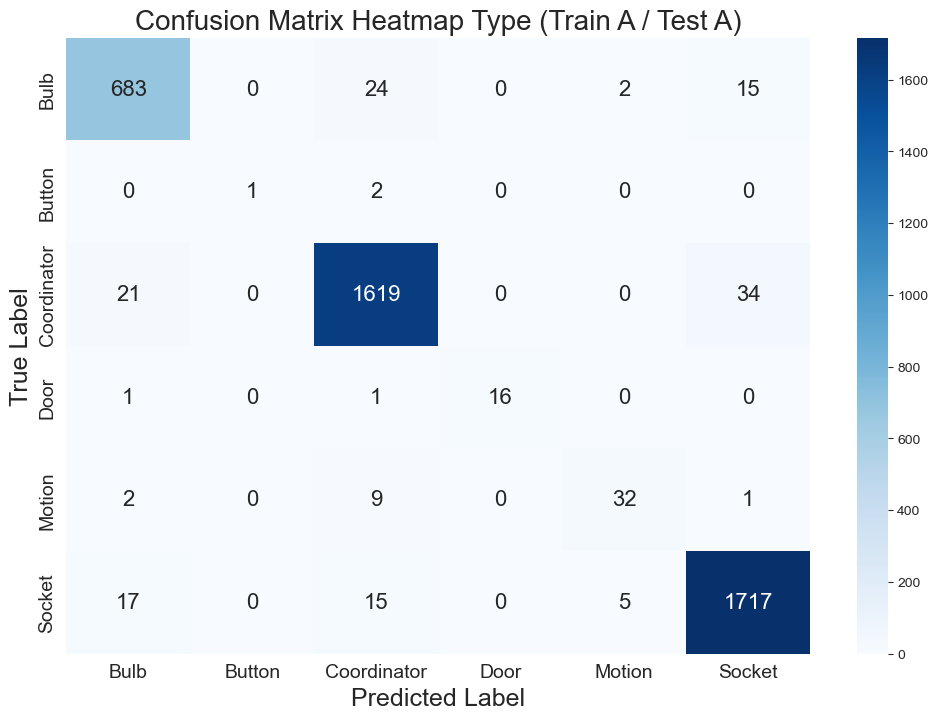

In [12]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)


X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train A / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


Category distribution:
2     8650
13    2949
12    2606
11    2385
3     1165
10     742
6      726
7      669
8      537
5      221
9      194
4      139
1       50
0       17
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      0.67      0.80         3
        Aqara Door 1       0.80      1.00      0.89         8
         Coordinator       0.97      0.97      0.97      1747
       Ledvance Bulb       0.92      0.92      0.92       229
Ledvance Smart+ Plug       0.93      0.80      0.86        35
    Ledvance Z3 Plug       0.79      0.76      0.78        41
           Moes Bulb       0.95      0.89      0.92       132
      Philips Lamp 1       0.81      0.72      0.76       122
      Philips Lamp 2       0.83      0.88      0.85        97
      Philips Lamp 3       0.82      0.79      0.80        42
      Philips Motion       0.83      0.83      0.83       145
        Power Plug 1       0.95      0.93      0.94 

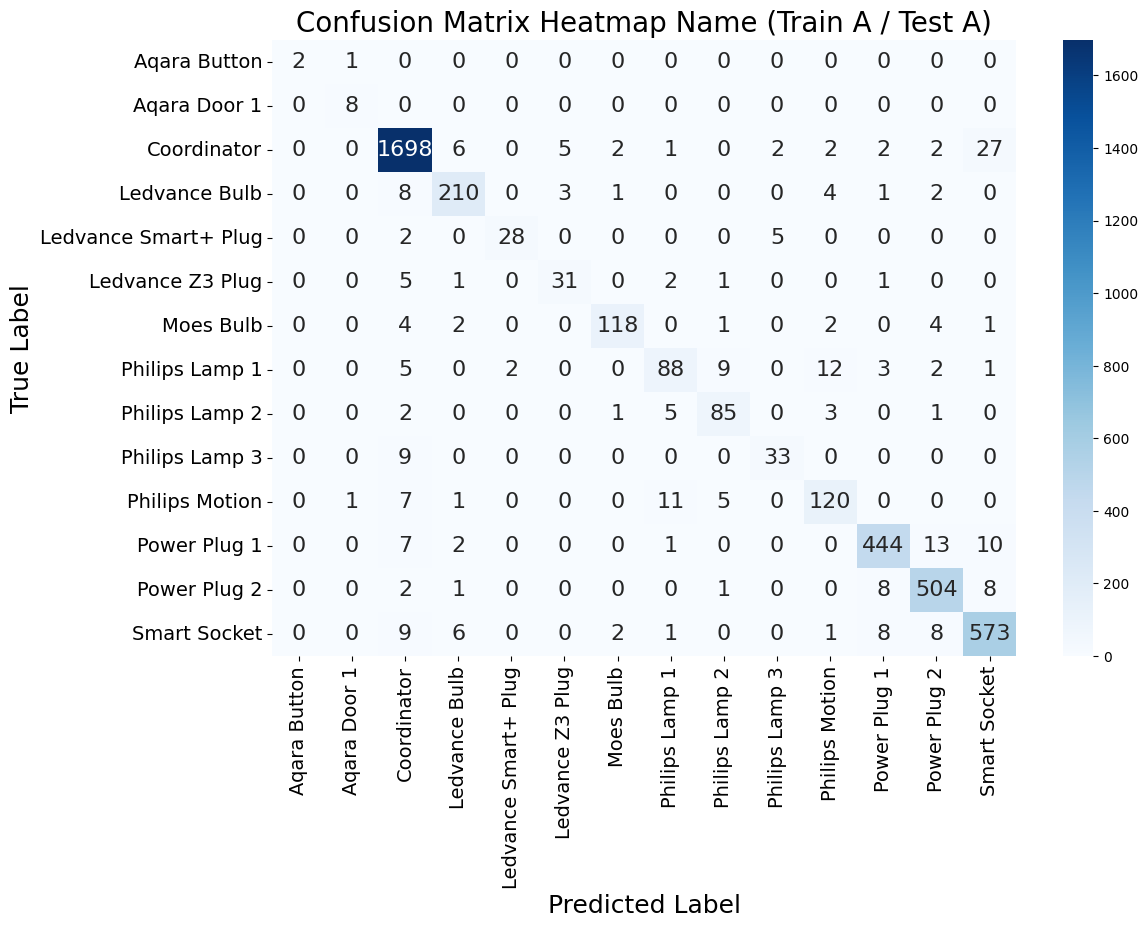

In [1]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
Device Type
Coordinator    8650
Socket         8300
Bulb           3839
Motion          206
Door             69
Button           17
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier

Fold 1/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:07:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9694
  Precision (avg): 0.9463
  Recall (avg):    0.9406
  F1-Macro:        0.9433
  F1-Weighted:     0.9694

Fold 2/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:08:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9720
  Precision (avg): 0.9663
  Recall (avg):    0.9022
  F1-Macro:        0.9297
  F1-Weighted:     0.9719

Fold 3/5:
----------------------------------------


...

  Accuracy:        0.9658
  Precision (avg): 0.9489
  Recall (avg):    0.9591
  F1-Macro:        0.9531
  F1-Weighted:     0.9660

Fold 4/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:08:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9715
  Precision (avg): 0.9555
  Recall (avg):    0.9624
  F1-Macro:        0.9586
  F1-Weighted:     0.9716

Fold 5/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:08:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9746
  Precision (avg): 0.9275
  Recall (avg):    0.9562
  F1-Macro:        0.9399
  F1-Weighted:     0.9746

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.9707 ± 0.0029
Precision (avg): 0.9489 ± 0.0128
Recall (avg):    0.9441 ± 0.0223
F1-Macro:        0.9449 ± 0.0101
F1-Weighted:     0.9707 ± 0.0029

MERGED CLASSIFICATION REPORT (All Folds Combined)
              precision    recall  f1-score   support

        Bulb       0.95      0.97      0.96      3839
      Button       0.94      1.00      0.97        17
 Coordinator       0.98      0.97      0.97      8650
        Door       0.97      0.91      0.94        69
      Motion       0.86      0.83      0.85       206
      Socket       0.97      0.98      0.98      8300

    accuracy                           0.97     21081
   macro avg       0.95      0.94      0.94     21081
weighted avg       0.97      0.97      0.97     21081



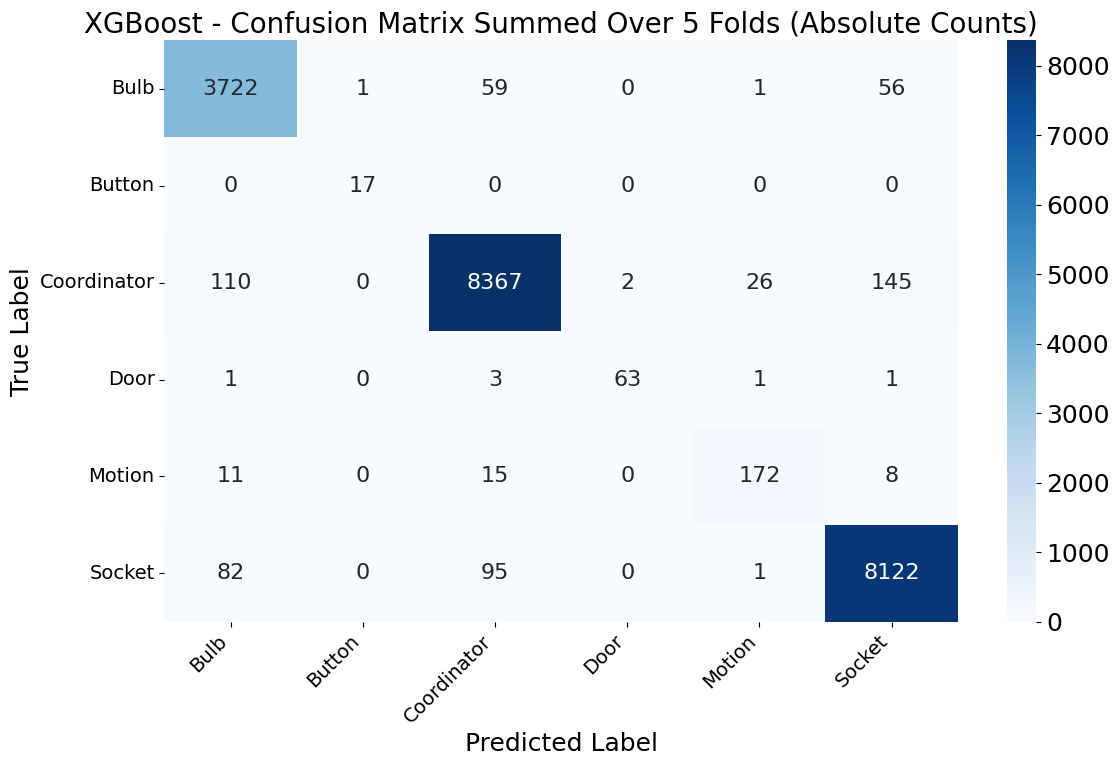

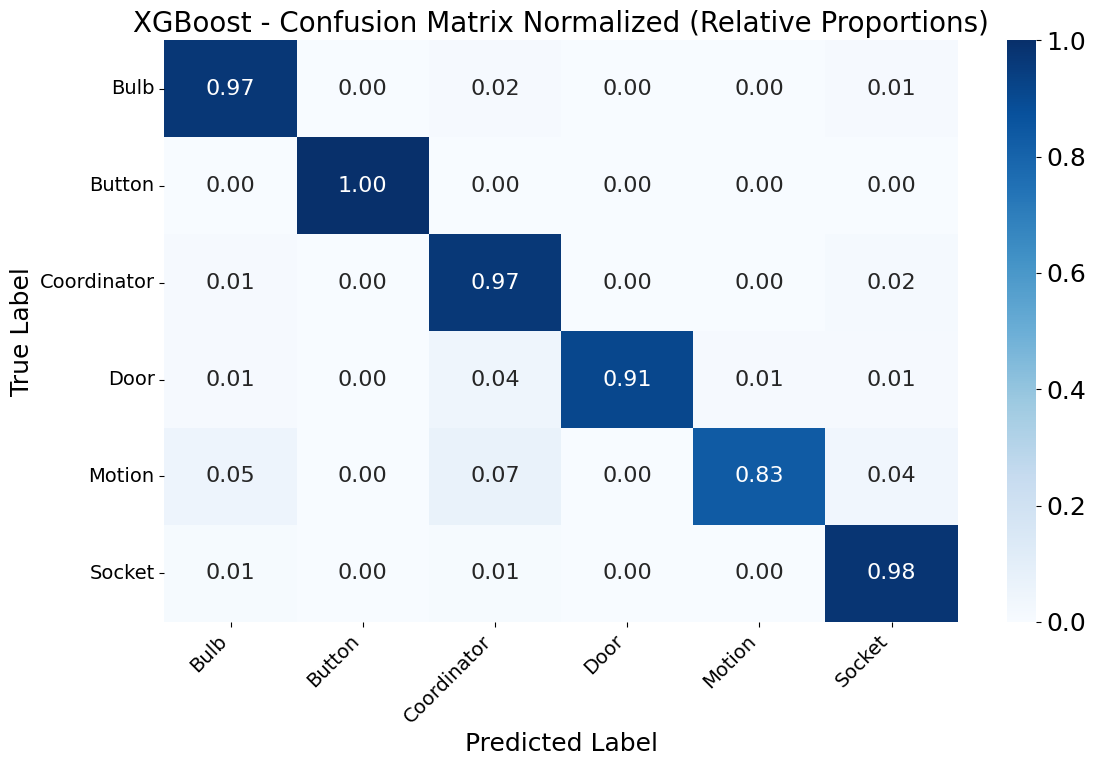


Confusion matrices saved to /mnt/user-data/outputs/


In [ ]:
# Classification with 5-Fold Cross-Validation using XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())
print()

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Convert class weights to sample weights for XGBoost
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        colsample_bytree=0.4,
        gamma=0,
        learning_rate=0.2,
        max_depth=8,
        min_child_weight=0.5,
        n_estimators=300,
        subsample=1
    )
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict
    y_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Summed Over 5 Folds (Absolute Counts)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_xgboost_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(12, 8))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Normalized (Relative Proportions)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_xgboost_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")

Category distribution:
3     8650
10    4991
11    2949
8     1400
4     1165
9      742
7      726
6      221
5      139
1       62
0       17
13      10
12       7
2        2
Name: count, dtype: int64

Number of classes: 14
Total samples: 21081

5-FOLD CROSS-VALIDATION RESULTS

Fold 1/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


  Accuracy:        0.9407
  Precision (avg): 0.8527
  Recall (avg):    0.8443
  F1-Macro:        0.8483
  F1-Weighted:     0.9405

Fold 2/5:
----------------------------------------
  Accuracy:        0.9469
  Precision (avg): 0.8733
  Recall (avg):    0.8268
  F1-Macro:        0.8479
  F1-Weighted:     0.9465

Fold 3/5:
----------------------------------------
  Accuracy:        0.9454
  Precision (avg): 0.8572
  Recall (avg):    0.8068
  F1-Macro:        0.8253
  F1-Weighted:     0.9451

Fold 4/5:
----------------------------------------
  Accuracy:        0.9459
  Precision (avg): 0.9019
  Recall (avg):    0.8501
  F1-Macro:        0.8689
  F1-Weighted:     0.9457

Fold 5/5:
----------------------------------------
  Accuracy:        0.9473
  Precision (avg): 0.8778
  Recall (avg):    0.7845
  F1-Macro:        0.8185
  F1-Weighted:     0.9469

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.9453 ± 0.0024
Precision (avg): 0.8726 ± 0.0174
Recall (avg):    0.8225 ± 0.0243
F1-M

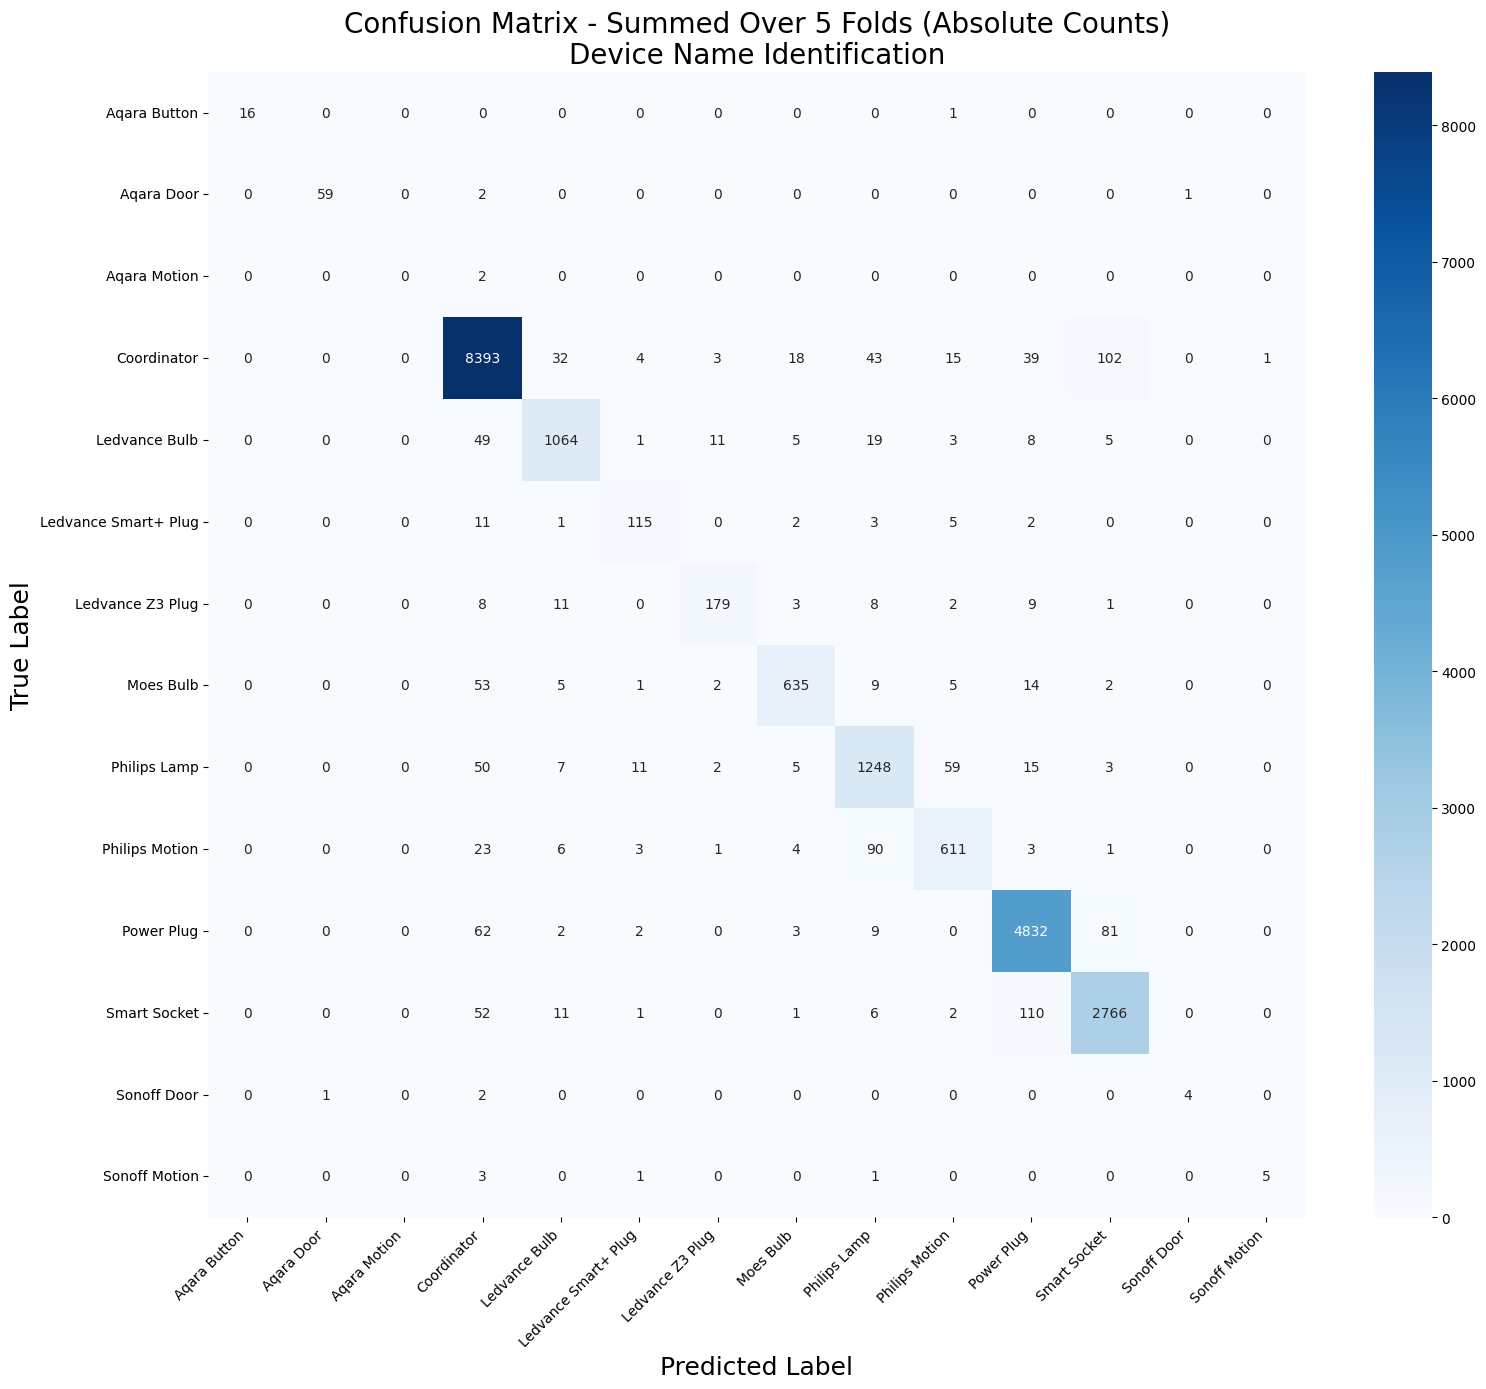

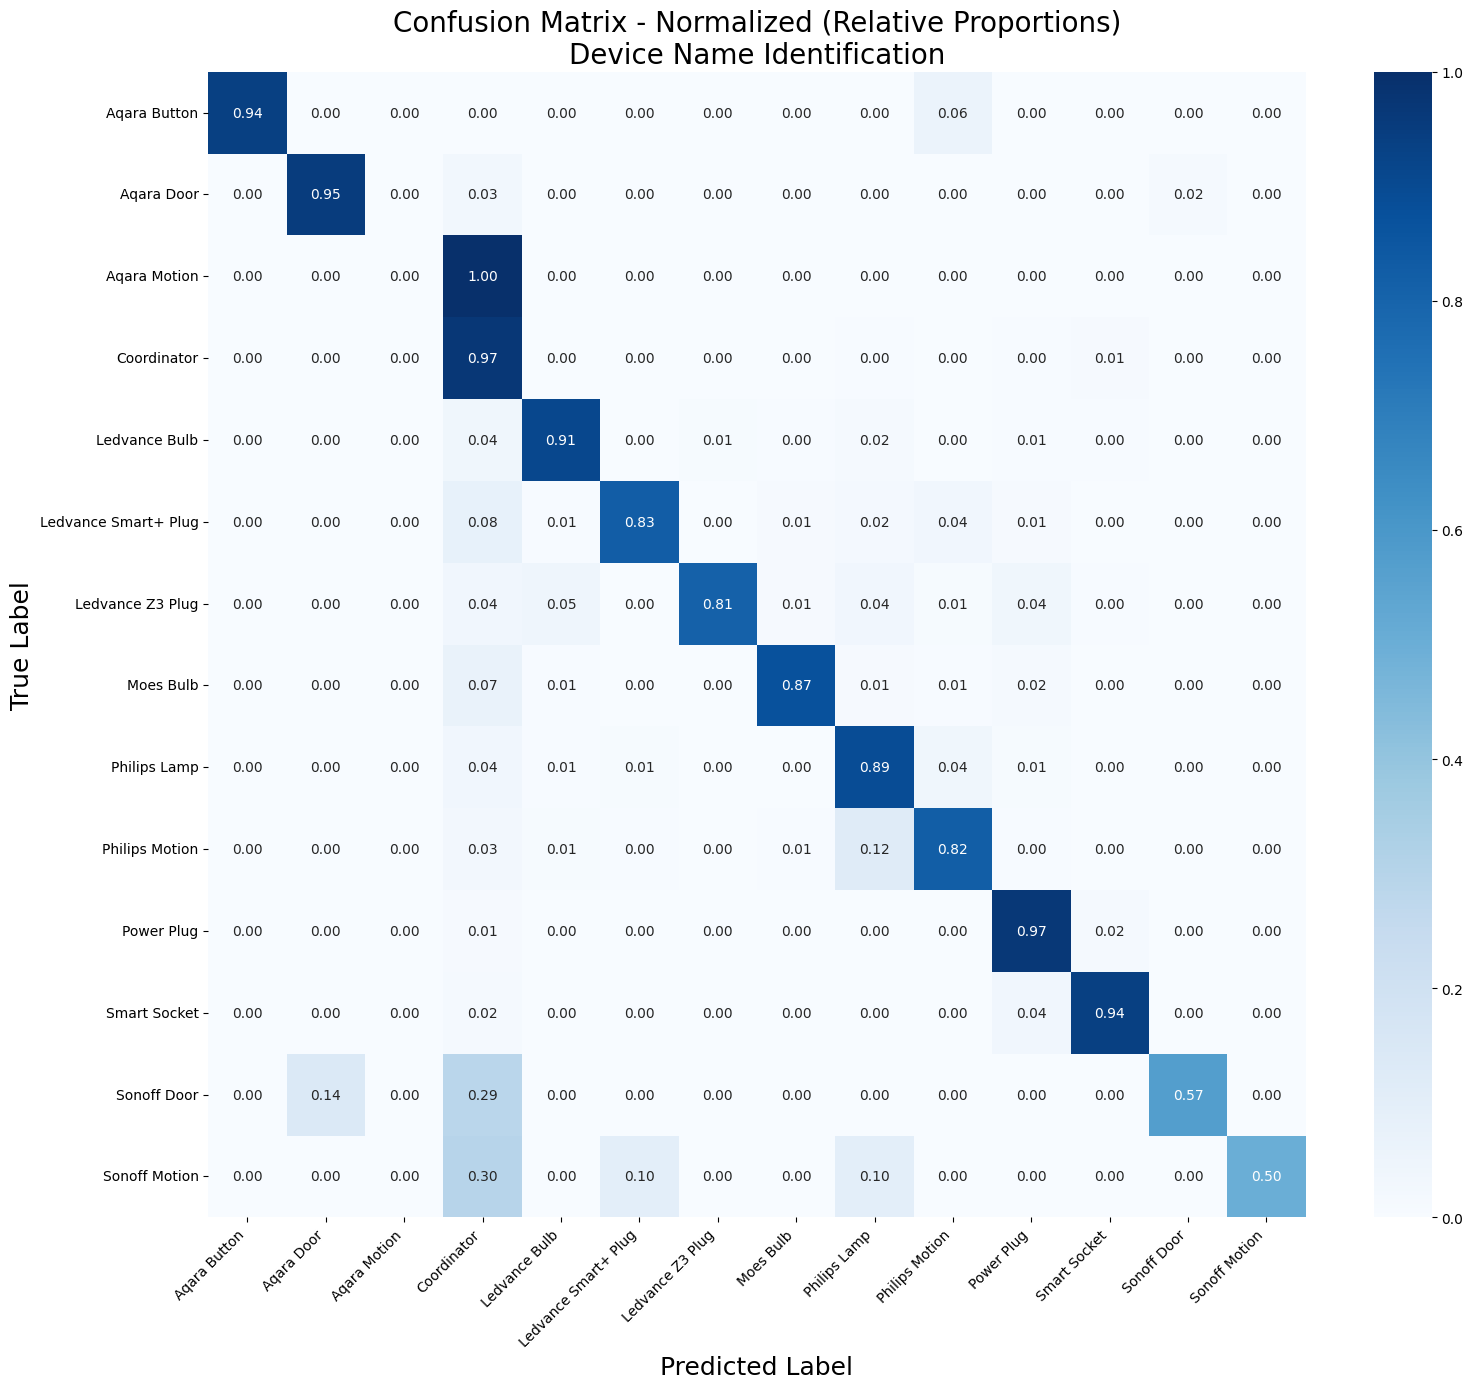


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_confusion_matrix_absolute.png
  - identification_confusion_matrix_relative.png


In [ ]:
# Identification with 5-Fold Cross-Validation
import pandas as pd
import re
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, col_name = "Device Name",  min_samples=5):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data[col_name].isin(classes_to_keep)].copy()
    return filtered_data

def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized

data["Device Name General"] = data["Device Name"].apply(generalize_device_name)

data = filter_small_classes(data, col_name="Device Name General", min_samples=10)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"])



y = data["Device Name General"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Train model
    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_confusion_matrix_absolute.png")
print("  - identification_confusion_matrix_relative.png")

Category distribution:
3     8650
14    2949
13    2606
12    2385
4     1165
11     742
7      726
8      669
9      537
6      221
10     194
5      139
1       50
0       17
2       12
16       9
15       6
Name: count, dtype: int64

Number of classes: 17
Total samples: 21077

5-FOLD CROSS-VALIDATION RESULTS

Fold 1/5:
----------------------------------------
  Accuracy:        0.9303
  Precision (avg): 0.9101
  Recall (avg):    0.8751
  F1-Macro:        0.8873
  F1-Weighted:     0.9302

Fold 2/5:
----------------------------------------
  Accuracy:        0.9435
  Precision (avg): 0.8796
  Recall (avg):    0.8267
  F1-Macro:        0.8424
  F1-Weighted:     0.9433

Fold 3/5:
----------------------------------------
  Accuracy:        0.9345
  Precision (avg): 0.8540
  Recall (avg):    0.8262
  F1-Macro:        0.8328
  F1-Weighted:     0.9342

Fold 4/5:
----------------------------------------
  Accuracy:        0.9340
  Precision (avg): 0.9320
  Recall (avg):    0.8663
  F1-Macro:

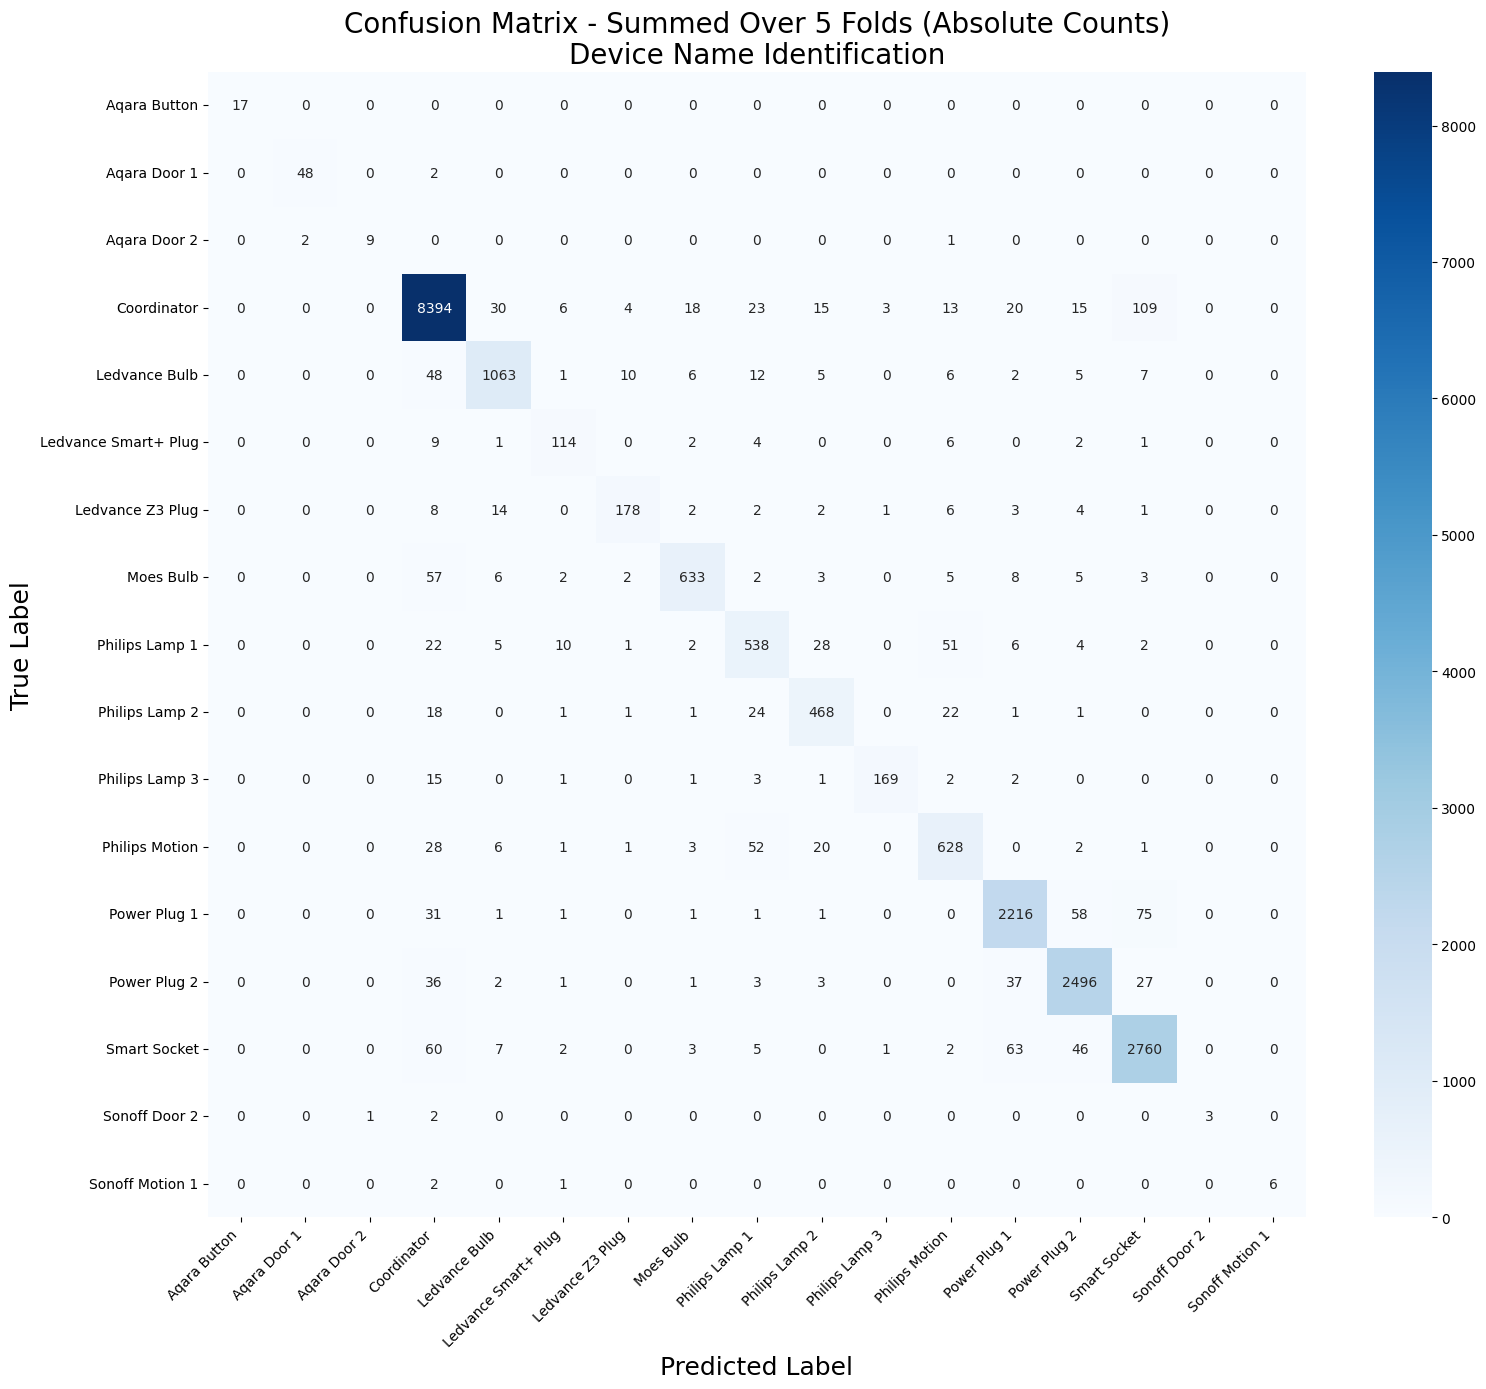

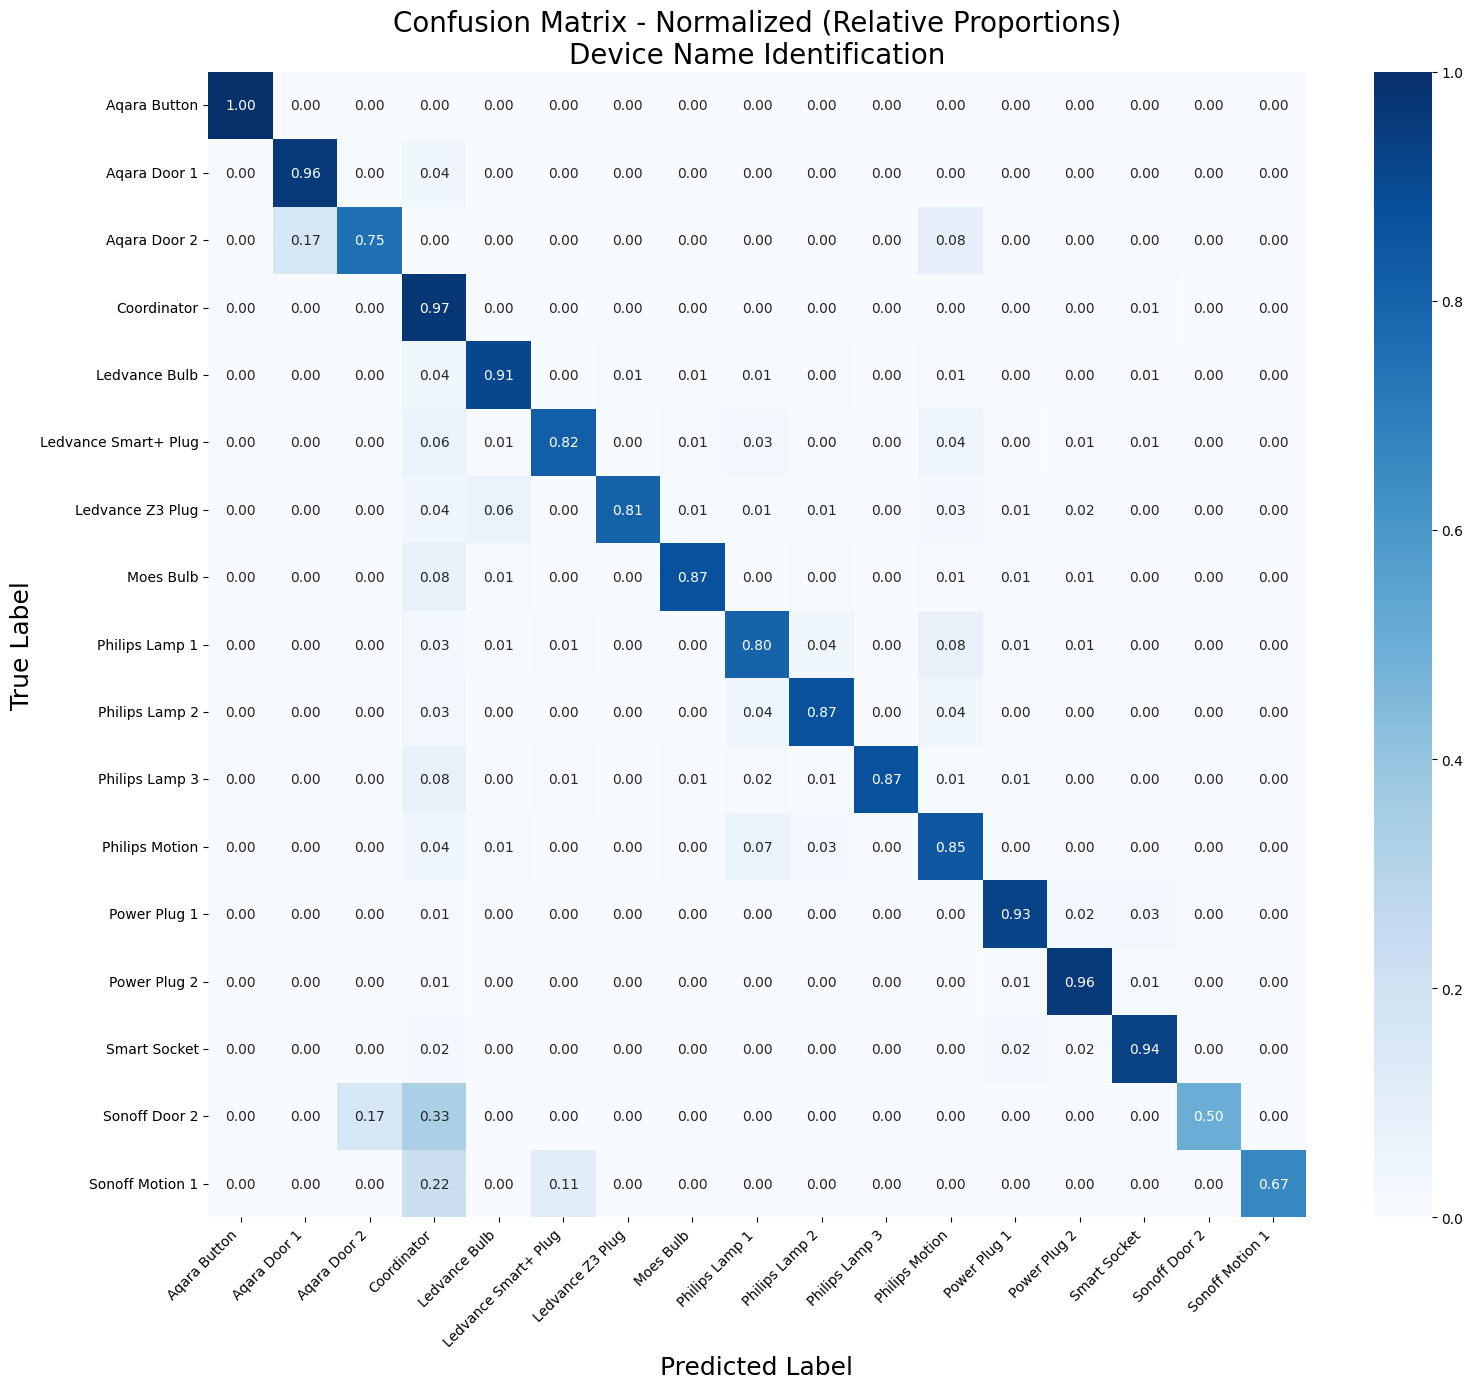


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_confusion_matrix_absolute.png
  - identification_confusion_matrix_relative.png


In [4]:
# Identification with 5-Fold Cross-Validation
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=5):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Name"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Train model
    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_confusion_matrix_absolute.png")
print("  - identification_confusion_matrix_relative.png")

Category distribution:
2     8650
9     4991
10    2949
7     1400
3     1165
8      742
6      726
5      221
4      139
1       62
0       17
11      10
Name: count, dtype: int64

Number of classes: 12
Total samples: 21072

5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier

Fold 1/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:27:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9383
  Precision (avg): 0.8815
  Recall (avg):    0.8779
  F1-Macro:        0.8794
  F1-Weighted:     0.9385

Fold 2/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:27:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9495
  Precision (avg): 0.8601
  Recall (avg):    0.8456
  F1-Macro:        0.8523
  F1-Weighted:     0.9493

Fold 3/5:
----------------------------------------


...

  Accuracy:        0.9414
  Precision (avg): 0.9383
  Recall (avg):    0.8786
  F1-Macro:        0.9010
  F1-Weighted:     0.9415

Fold 4/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:29:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9438
  Precision (avg): 0.9344
  Recall (avg):    0.8959
  F1-Macro:        0.9079
  F1-Weighted:     0.9439

Fold 5/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:29:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9480
  Precision (avg): 0.9344
  Recall (avg):    0.8865
  F1-Macro:        0.9031
  F1-Weighted:     0.9482

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.9442 ± 0.0041
Precision (avg): 0.9097 ± 0.0325
Recall (avg):    0.8769 ± 0.0170
F1-Macro:        0.8887 ± 0.0207
F1-Weighted:     0.9443 ± 0.0040

MERGED CLASSIFICATION REPORT (All Folds Combined)
                      precision    recall  f1-score   support

        Aqara Button       0.94      0.94      0.94        17
          Aqara Door       1.00      0.95      0.98        62
         Coordinator       0.98      0.96      0.97      8650
       Ledvance Bulb       0.94      0.93      0.93      1165
Ledvance Smart+ Plug       0.86      0.85      0.86       139
    Ledvance Z3 Plug       0.87      0.84      0.85       221
           Moes Bulb       0.94      0.90      0.92       726
        Philips Lamp       0.86      0.90      0.88      1400
      Philips Motion       0.87      0.87      0.87     

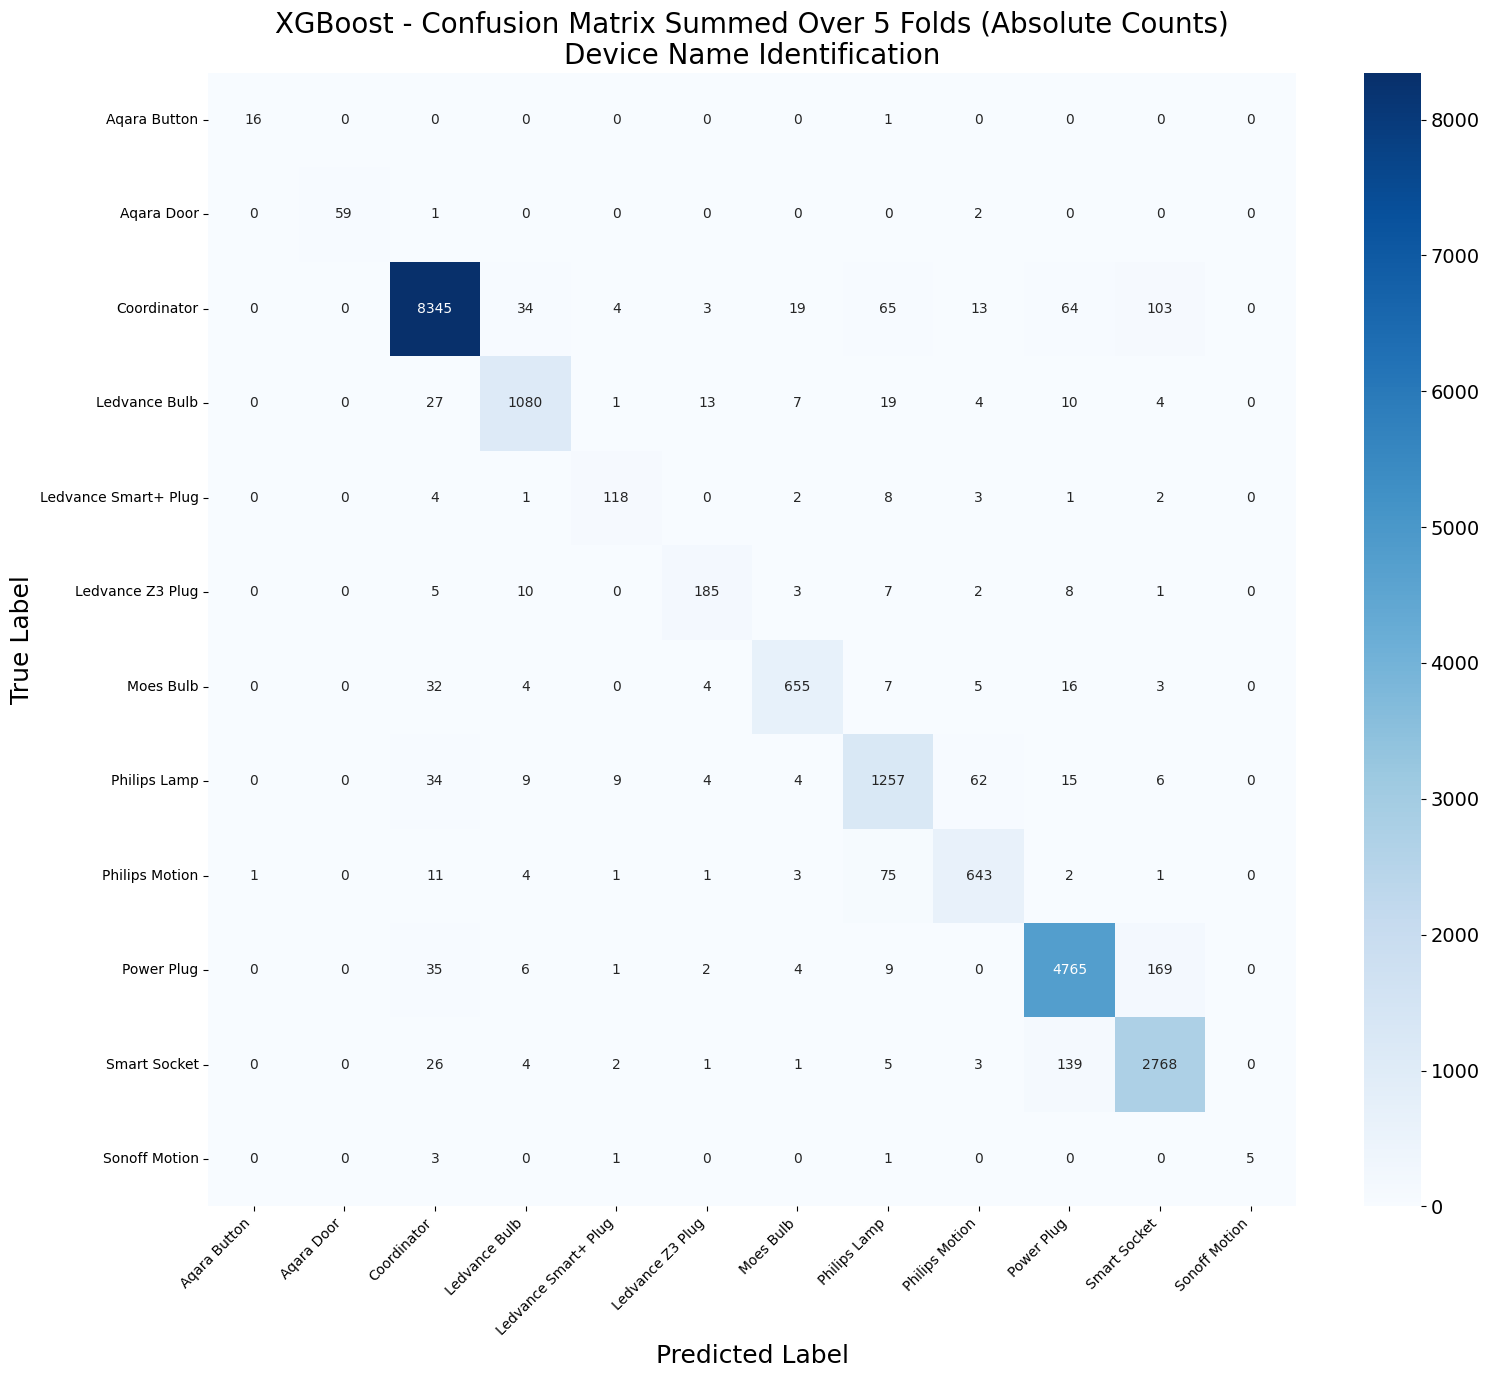

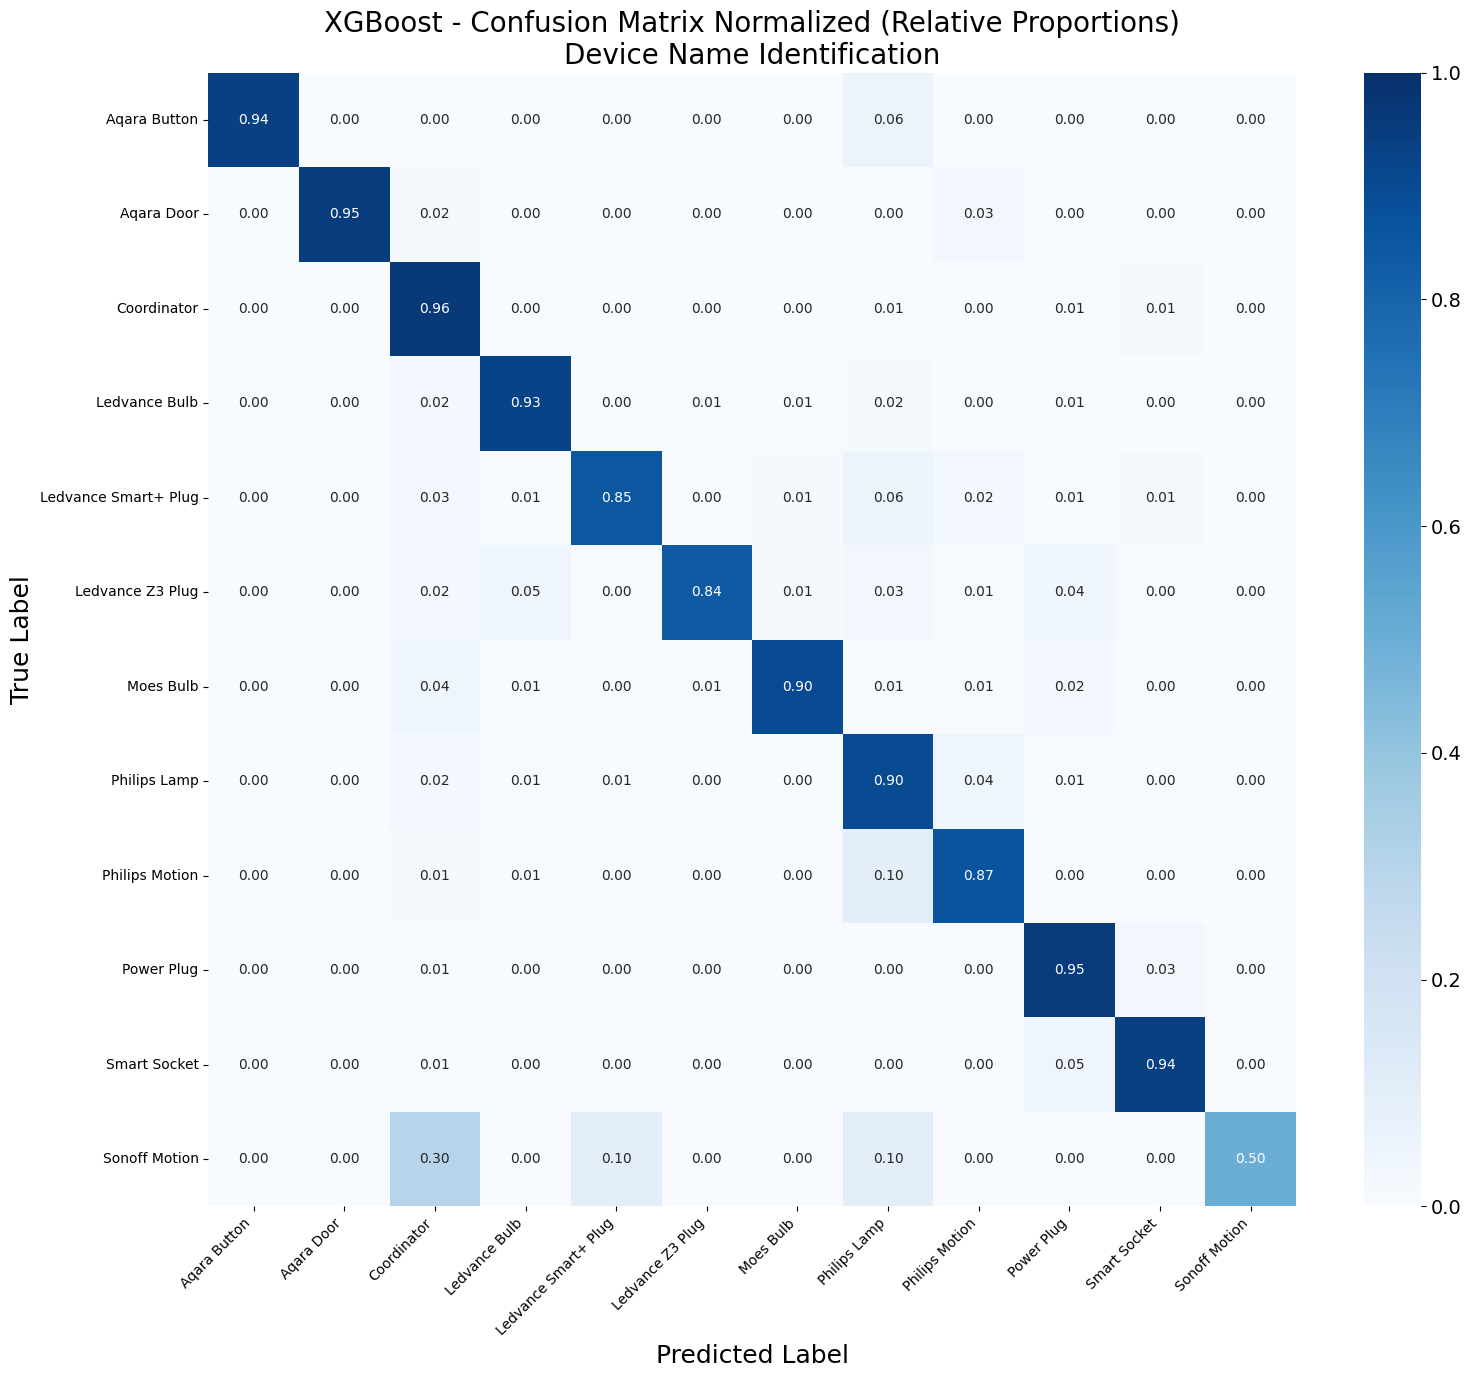


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_xgboost_confusion_matrix_absolute.png
  - identification_xgboost_confusion_matrix_relative.png


In [91]:
# Identification with 5-Fold Cross-Validation using XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, col_name = "Device Name",  min_samples=2):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data[col_name].isin(classes_to_keep)].copy()
    return filtered_data

def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized

data["Device Name General"] = data["Device Name"].apply(generalize_device_name)

data = filter_small_classes(data, col_name="Device Name General", min_samples=10)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"])



y = data["Device Name General"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Convert class weights to sample weights for XGBoost
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        colsample_bytree=0.4,
        gamma=0,
        learning_rate=0.2,
        max_depth=10,
        min_child_weight=0.2,
        n_estimators=300,
        subsample=0.8
    )
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict
    y_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_xgboost_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_xgboost_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_xgboost_confusion_matrix_absolute.png")
print("  - identification_xgboost_confusion_matrix_relative.png")

## Train B Test B

Category distribution:
Device Type
Socket         14573
Coordinator    11594
Bulb            4228
Motion           554
Door              45
Button            35
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.95      0.94      0.95       862
      Button       0.90      1.00      0.95         9
 Coordinator       0.98      0.97      0.97      2309
        Door       0.83      1.00      0.91         5
      Motion       0.96      0.99      0.97       117
      Socket       0.98      0.99      0.98      2904

    accuracy                           0.97      6206
   macro avg       0.93      0.98      0.96      6206
weighted avg       0.97      0.97      0.97      6206

Weighted F1-Score: 0.9745


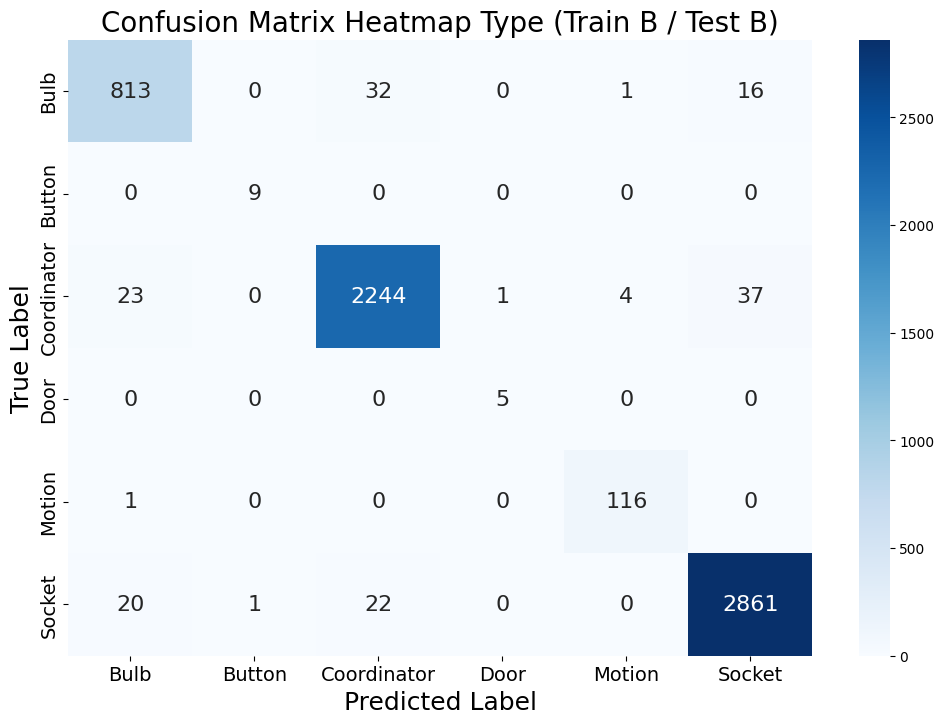

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)


X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train B / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


Category distribution:
Device Type
Socket         14573
Coordinator    11594
Bulb            4228
Motion           554
Door              45
Button            35
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION RESULTS

Fold 1/5:
----------------------------------------
  Accuracy:        0.9753
  Precision (avg): 0.9201
  Recall (avg):    0.9142
  F1-Macro:        0.9170
  F1-Weighted:     0.9753

Fold 2/5:
----------------------------------------
  Accuracy:        0.9684
  Precision (avg): 0.9507
  Recall (avg):    0.9122
  F1-Macro:        0.9291
  F1-Weighted:     0.9684

Fold 3/5:
----------------------------------------
  Accuracy:        0.9733
  Precision (avg): 0.9401
  Recall (avg):    0.9429
  F1-Macro:        0.9369
  F1-Weighted:     0.9733

Fold 4/5:
----------------------------------------
  Accuracy:        0.9694
  Precision (avg): 0.9764
  Recall (avg):    0.9408
  F1-Macro:        0.9563
  F1-Weighted:     0.9694

Fold 5/5:
----------------------------------------


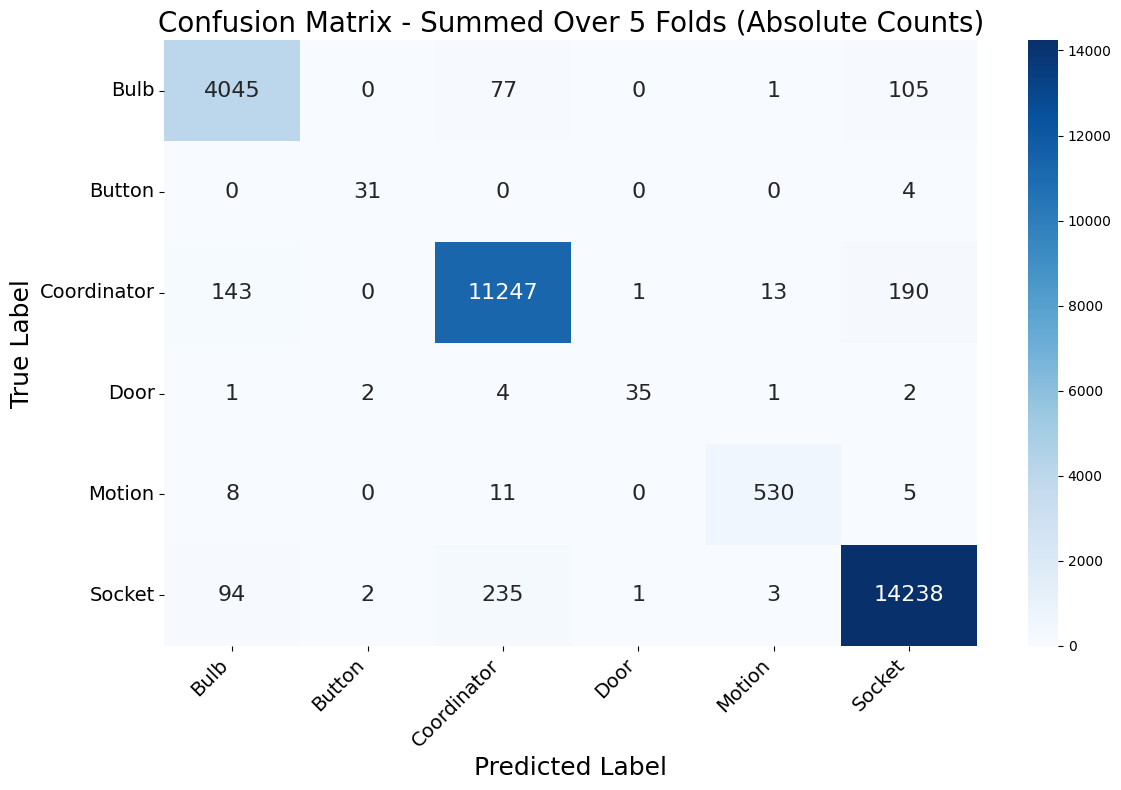

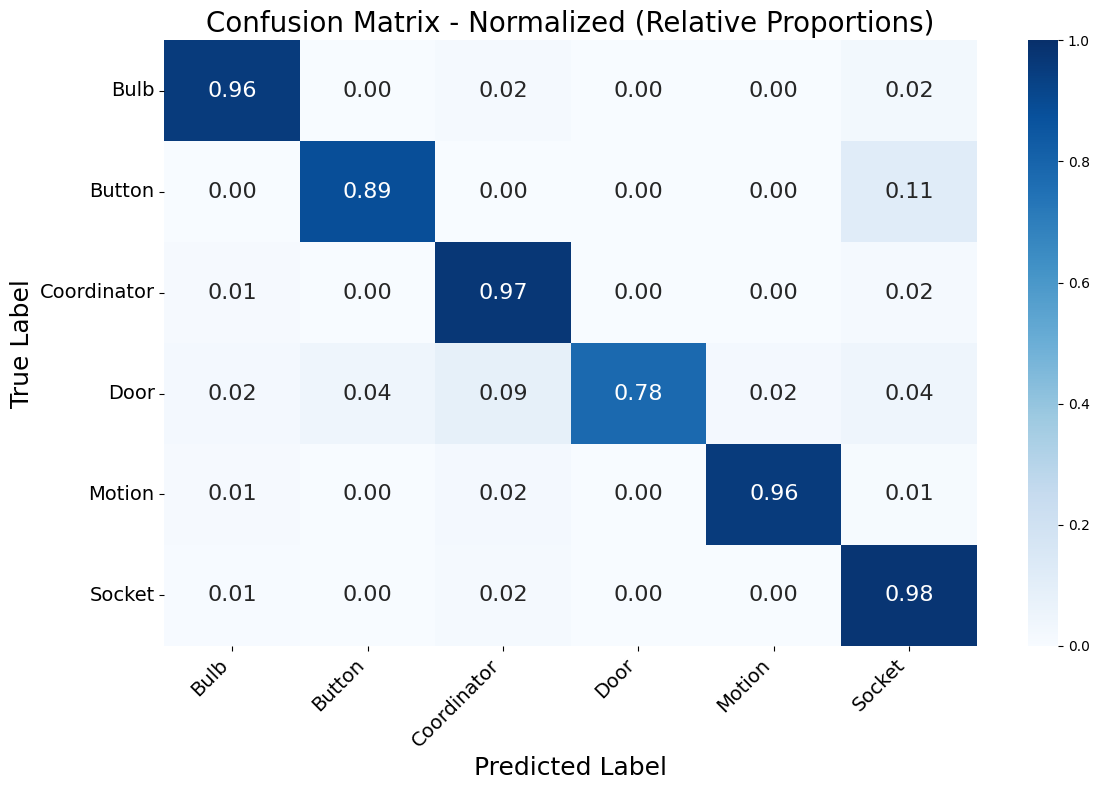


Confusion matrices saved to /mnt/user-data/outputs/


In [5]:
# Classification with 5-Fold Cross-Validation
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())
print()

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Train model
    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Summed Over 5 Folds (Absolute Counts)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(12, 8))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Normalized (Relative Proportions)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")

Category distribution:
Device Type
Socket         14573
Coordinator    11594
Bulb            4228
Motion           554
Door              45
Button            35
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier

Fold 1/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:36:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9733
  Precision (avg): 0.9296
  Recall (avg):    0.9425
  F1-Macro:        0.9348
  F1-Weighted:     0.9733

Fold 2/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:36:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9702
  Precision (avg): 0.9687
  Recall (avg):    0.9551
  F1-Macro:        0.9608
  F1-Weighted:     0.9702

Fold 3/5:
----------------------------------------


...

  Accuracy:        0.9744
  Precision (avg): 0.9339
  Recall (avg):    0.9447
  F1-Macro:        0.9345
  F1-Weighted:     0.9744

Fold 4/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:37:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9700
  Precision (avg): 0.9642
  Recall (avg):    0.9772
  F1-Macro:        0.9705
  F1-Weighted:     0.9701

Fold 5/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:37:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9729
  Precision (avg): 0.9704
  Recall (avg):    0.9669
  F1-Macro:        0.9679
  F1-Weighted:     0.9730

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.9722 ± 0.0017
Precision (avg): 0.9534 ± 0.0178
Recall (avg):    0.9573 ± 0.0132
F1-Macro:        0.9537 ± 0.0159
F1-Weighted:     0.9722 ± 0.0017

MERGED CLASSIFICATION REPORT (All Folds Combined)
              precision    recall  f1-score   support

        Bulb       0.94      0.98      0.96      4228
      Button       0.92      0.97      0.94        35
 Coordinator       0.98      0.96      0.97     11594
        Door       0.98      0.89      0.93        45
      Motion       0.92      0.97      0.94       554
      Socket       0.98      0.98      0.98     14573

    accuracy                           0.97     31029
   macro avg       0.95      0.96      0.95     31029
weighted avg       0.97      0.97      0.97     31029



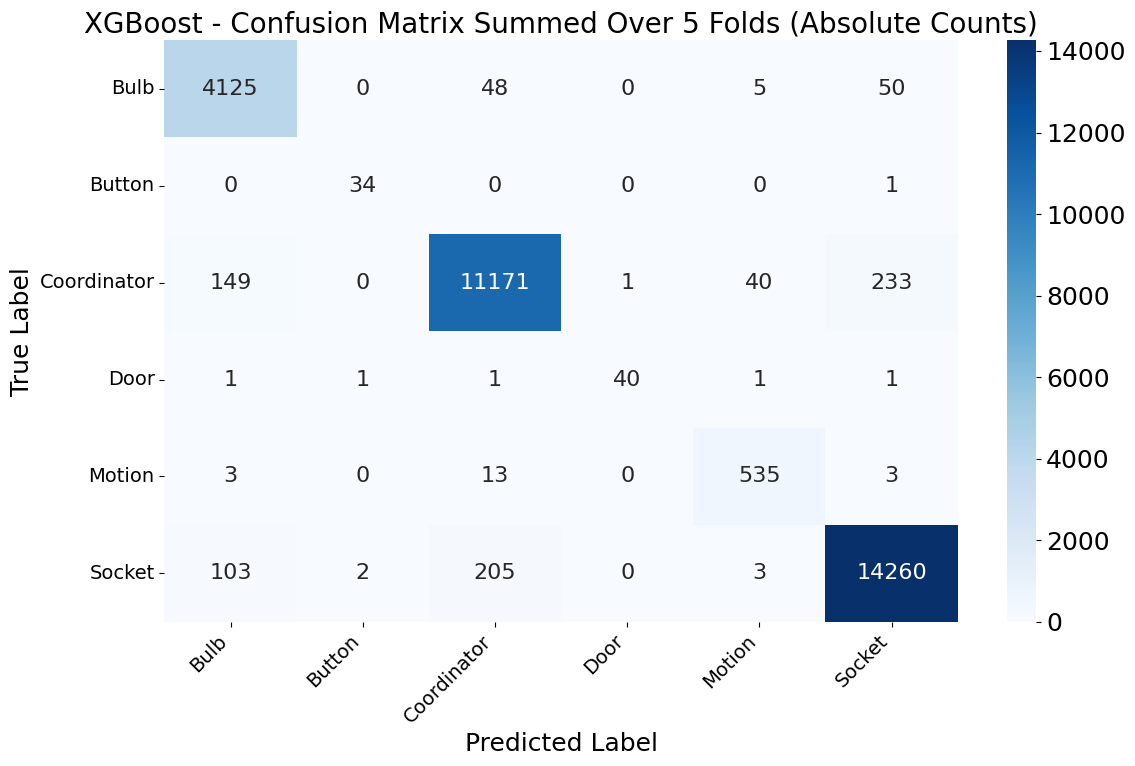

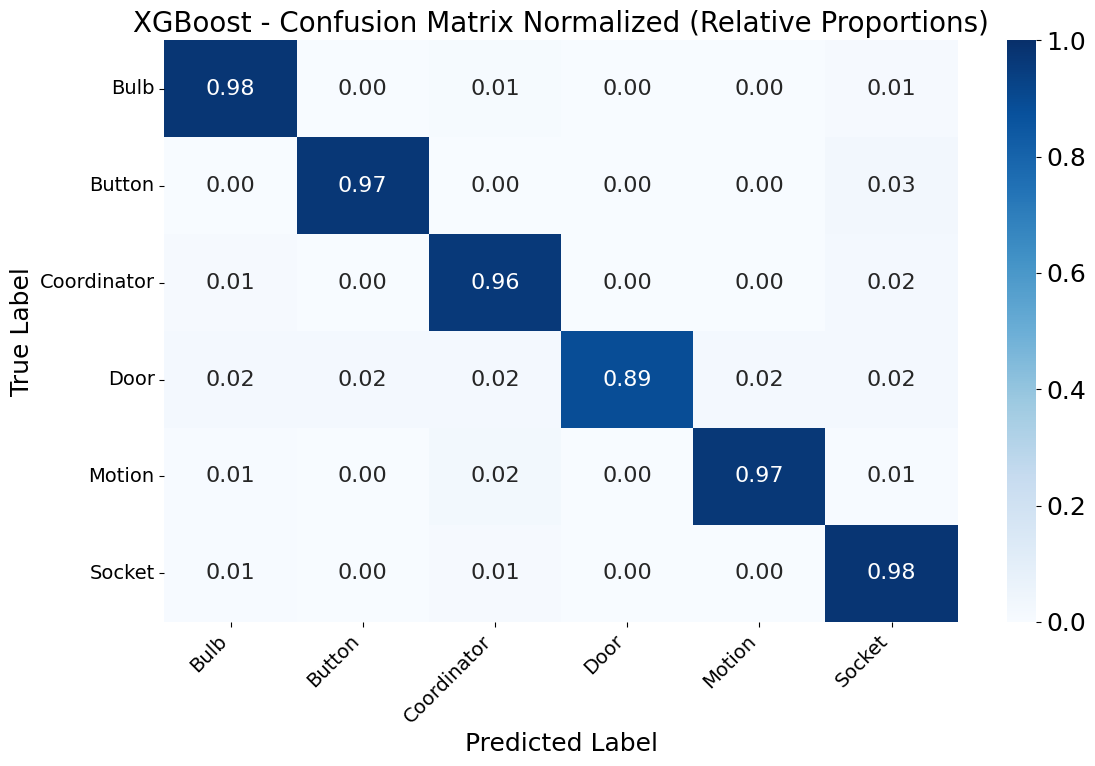


Confusion matrices saved to /mnt/user-data/outputs/


In [71]:
# Classification with 5-Fold Cross-Validation using XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())
print()

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Convert class weights to sample weights for XGBoost
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        colsample_bytree=0.4,
        gamma=0,
        learning_rate=0.2,
        max_depth=8,
        min_child_weight=0.5,
        n_estimators=300,
        subsample=1
    )
    

    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict
    y_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Summed Over 5 Folds (Absolute Counts)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_xgboost_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(12, 8))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Normalized (Relative Proportions)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/confusion_matrix_xgboost_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")

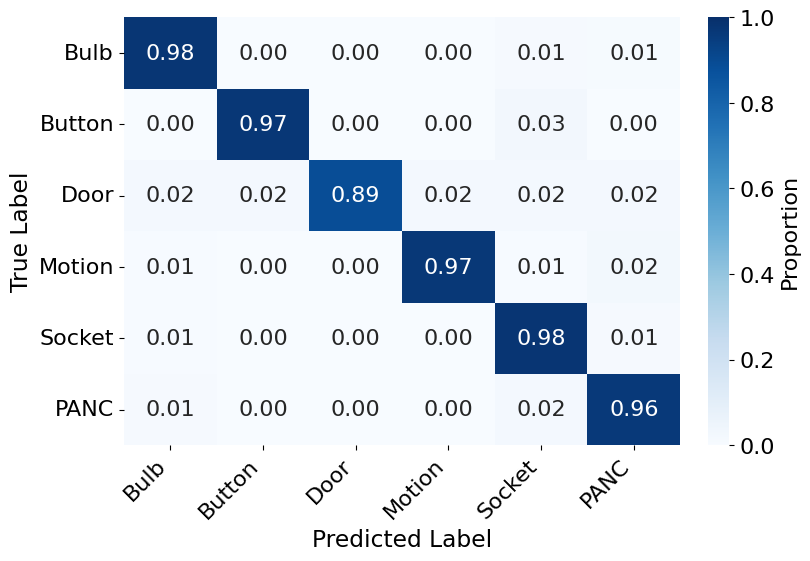

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl

# Reset to defaults and apply consistent styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# Define the new category order with Coordinator → PANC moved to the end
new_order = ['Bulb', 'Button', 'Door', 'Motion', 'Socket', 'PANC']

# Get indices for reordering based on original categories
# Original: ['Bulb', 'Button', 'Coordinator', 'Door', 'Motion', 'Socket']
original_categories = categories.tolist()
reorder_indices = []
for cat in new_order:
    if cat == 'PANC':
        reorder_indices.append(original_categories.index('Coordinator'))
    else:
        reorder_indices.append(original_categories.index(cat))

# Reorder confusion matrix (both rows and columns)
relative_cm_reordered = relative_cm[np.ix_(reorder_indices, reorder_indices)]

# ========== PLOT: Relative Confusion Matrix with PANC at end ==========
fig2, ax2 = plt.subplots(figsize=(8, 5.5), layout="constrained")

sns.heatmap(
    relative_cm_reordered, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=new_order, 
    yticklabels=new_order, 
    
    annot_kws={"size": 16, "weight": "normal"},
    vmin=0,
    vmax=1,
    linewidths=0,
    linecolor='lightgray',
    ax=ax2
)

ax2.set_xlabel("Predicted Label", fontsize='large')
ax2.set_ylabel("True Label", fontsize='large')
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=16, rotation=45, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=16, rotation=0)

# Adjust colorbar font size
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=16)
cbar2.set_label('Proportion', fontsize=16)

plt.savefig('./figures/confusion_matrix_relative_device_type_topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

Category distribution:
4     11594
15     5506
13     4682
14     3994
5      1312
9      1184
11      942
12      511
8       405
10      385
7       321
6        70
0        35
18       33
2        29
3        10
16        6
17        5
1         5
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.90      1.00      0.95         9
        Aqara Door 1       1.00      1.00      1.00         1
        Aqara Door 2       1.00      1.00      1.00         2
        Aqara Motion       1.00      1.00      1.00         1
         Coordinator       0.97      0.97      0.97      2309
       Ledvance Bulb       0.94      0.88      0.91       284
Ledvance Smart+ Plug       0.91      0.91      0.91        11
    Ledvance Z3 Plug       0.85      0.66      0.75        62
           Moes Bulb       0.98      0.91      0.94        92
      Philips Lamp 1       0.89      0.93      0.91       232
      Philips Lamp 2       0.90      0.8

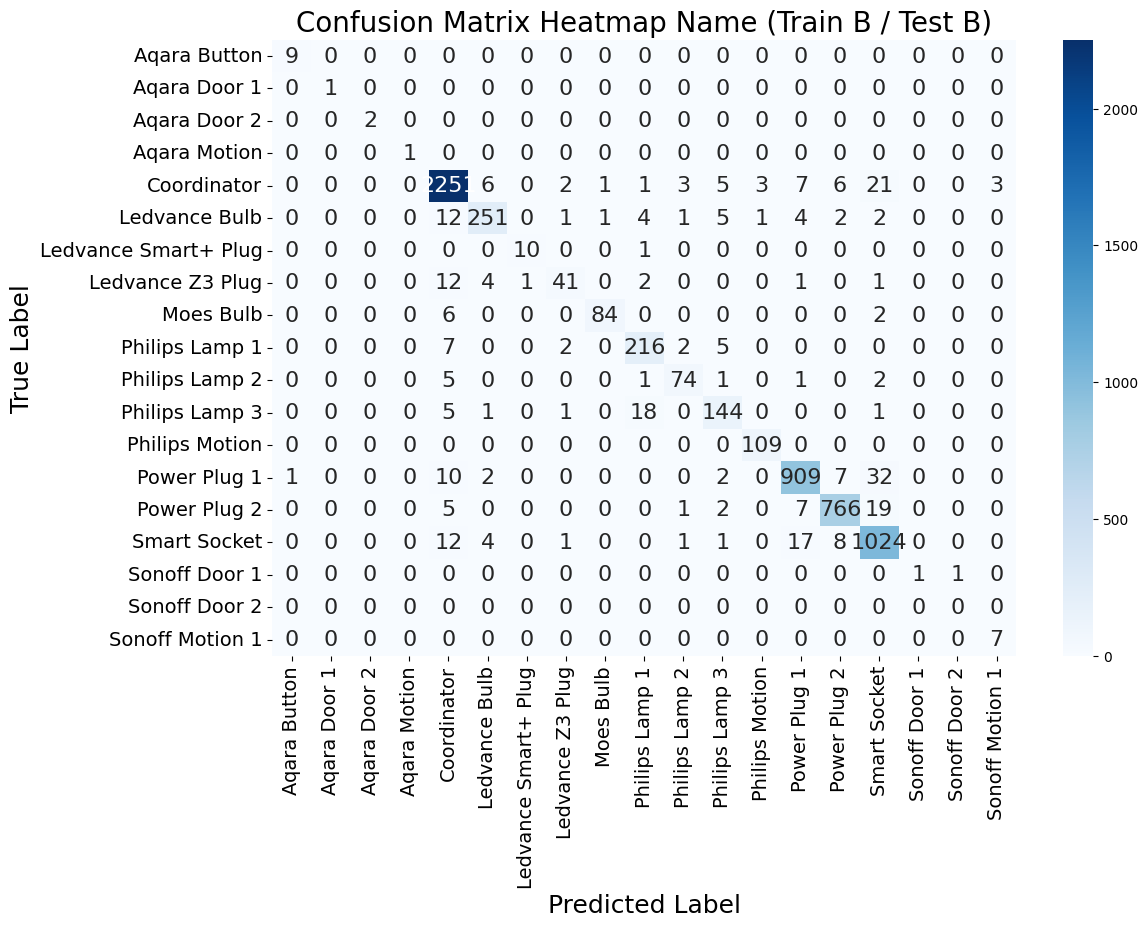

In [11]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=5):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train B / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
3     11594
10     8676
11     5506
8      2511
4      1312
9       511
7       405
6       321
5        70
0        35
1        34
13       33
12       11
2        10
Name: count, dtype: int64

Number of classes: 14
Total samples: 31029

5-FOLD CROSS-VALIDATION RESULTS

Fold 1/5:
----------------------------------------
  Accuracy:        0.9578
  Precision (avg): 0.9230
  Recall (avg):    0.9323
  F1-Macro:        0.9249
  F1-Weighted:     0.9577

Fold 2/5:
----------------------------------------
  Accuracy:        0.9568
  Precision (avg): 0.9242
  Recall (avg):    0.9204
  F1-Macro:        0.9178
  F1-Weighted:     0.9567

Fold 3/5:
----------------------------------------
  Accuracy:        0.9602
  Precision (avg): 0.9278
  Recall (avg):    0.8713
  F1-Macro:        0.8886
  F1-Weighted:     0.9601

Fold 4/5:
----------------------------------------
  Accuracy:        0.9549
  Precision (avg): 0.9443
  Recall (avg):    0.8800
  F1-Macro:        0.9042
  F1

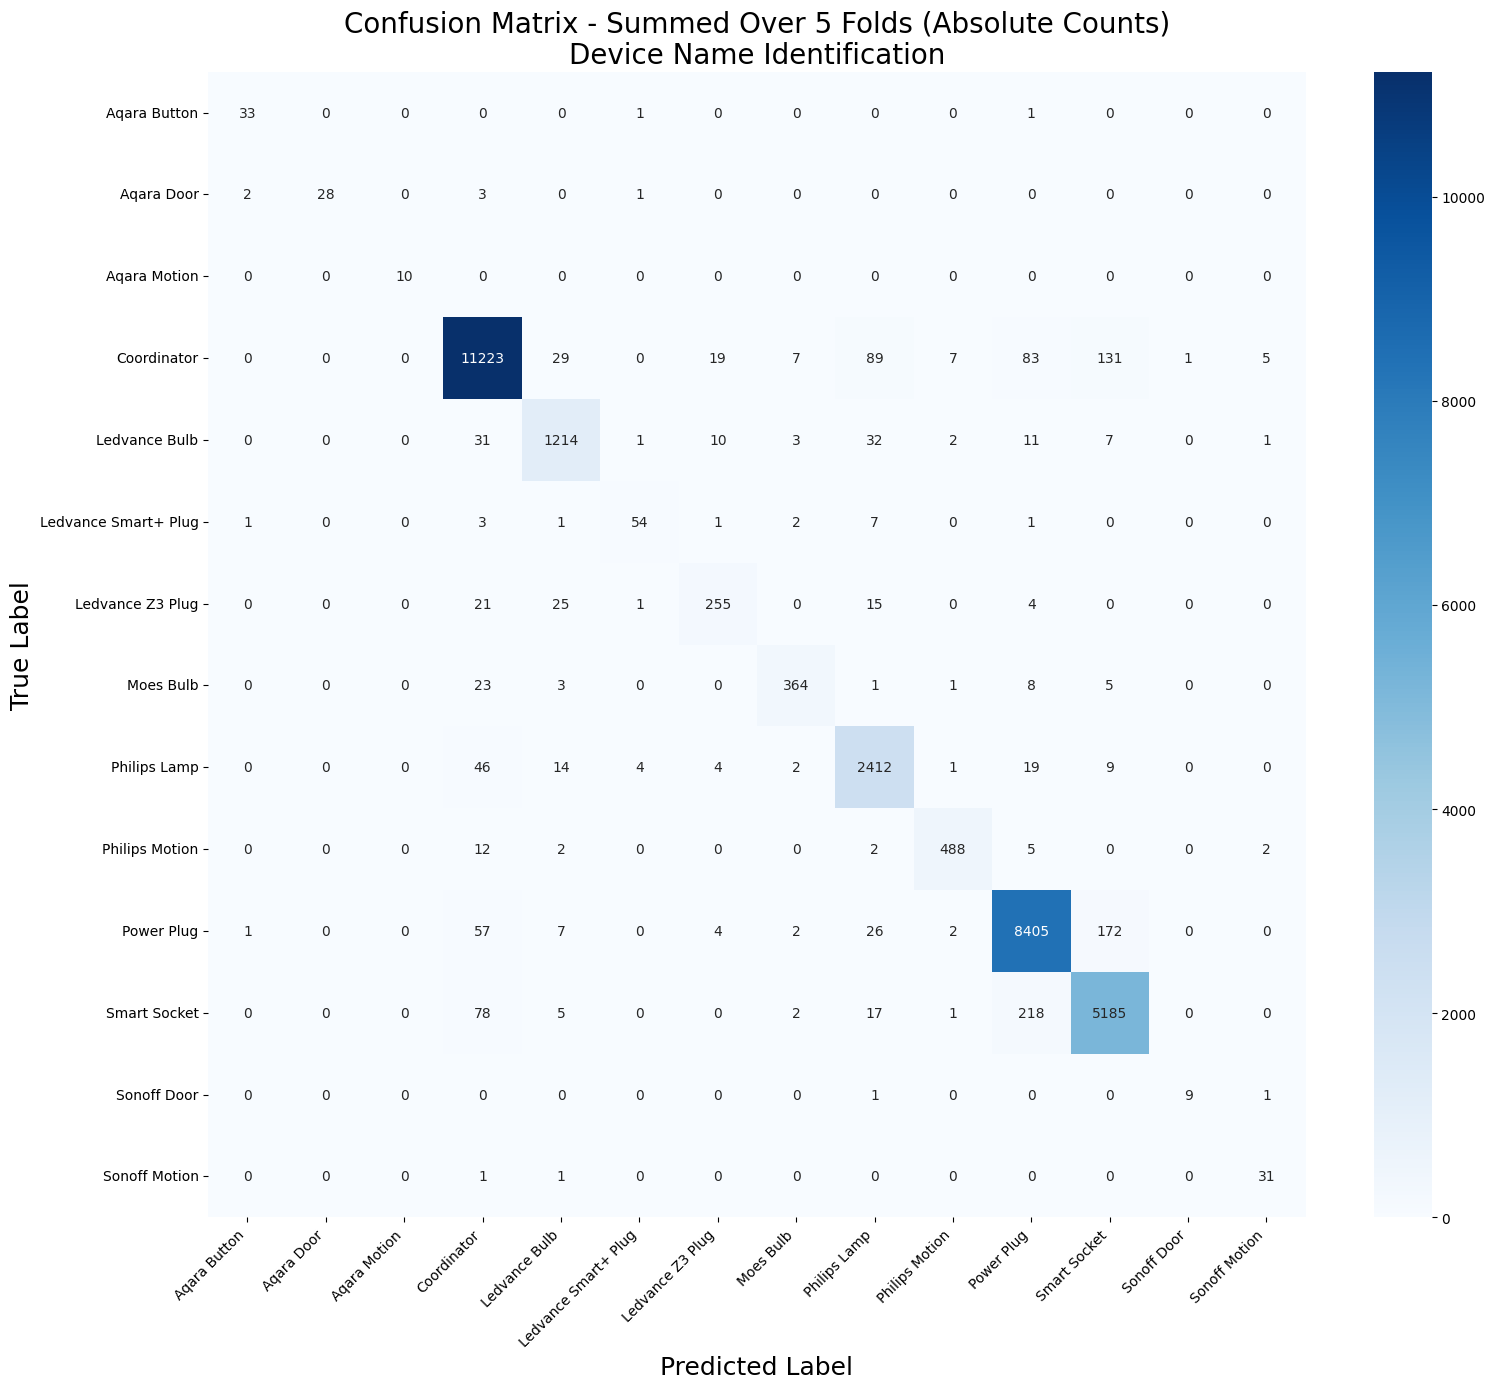

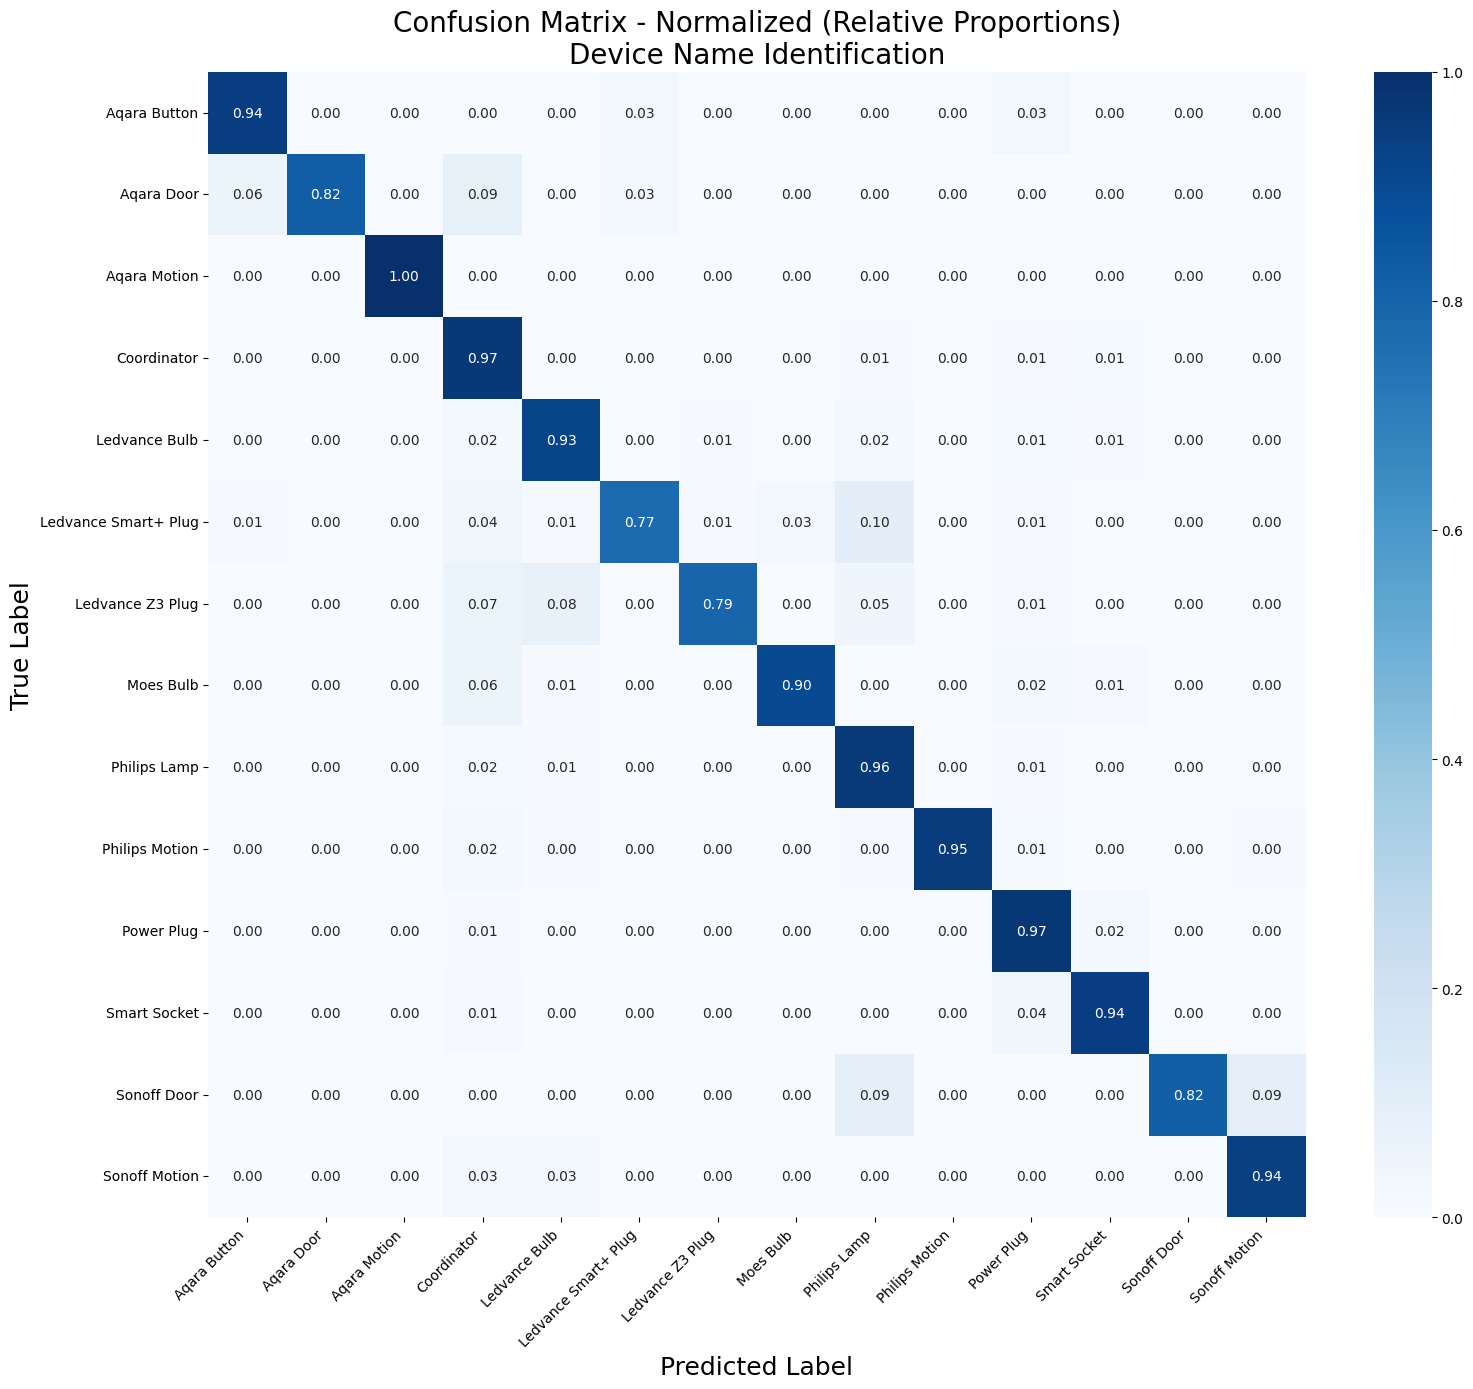


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_confusion_matrix_absolute.png
  - identification_confusion_matrix_relative.png


In [6]:
# Identification with 5-Fold Cross-Validation
import pandas as pd
import re
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, col_name = "Device Name",  min_samples=5):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data[col_name].isin(classes_to_keep)].copy()
    return filtered_data

def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized

data["Device Name General"] = data["Device Name"].apply(generalize_device_name)

data = filter_small_classes(data, col_name="Device Name General", min_samples=10)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"])



y = data["Device Name General"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Train model
    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_confusion_matrix_absolute.png")
print("  - identification_confusion_matrix_relative.png")

Category distribution:
3     11594
10     8676
11     5506
8      2511
4      1312
9       511
7       405
6       321
5        70
0        35
1        34
13       33
12       11
2        10
Name: count, dtype: int64

Number of classes: 14
Total samples: 31029

5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier

Fold 1/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:17:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9513
  Precision (avg): 0.9239
  Recall (avg):    0.9504
  F1-Macro:        0.9345
  F1-Weighted:     0.9516

Fold 2/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:18:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9470
  Precision (avg): 0.9070
  Recall (avg):    0.9395
  F1-Macro:        0.9187
  F1-Weighted:     0.9471

Fold 3/5:
----------------------------------------


...

  Accuracy:        0.9546
  Precision (avg): 0.9453
  Recall (avg):    0.9078
  F1-Macro:        0.9184
  F1-Weighted:     0.9547

Fold 4/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:20:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9525
  Precision (avg): 0.9540
  Recall (avg):    0.8980
  F1-Macro:        0.9187
  F1-Weighted:     0.9526

Fold 5/5:
----------------------------------------


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:21:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9494
  Precision (avg): 0.9318
  Recall (avg):    0.9267
  F1-Macro:        0.9287
  F1-Weighted:     0.9495

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.9509 ± 0.0026
Precision (avg): 0.9324 ± 0.0164
Recall (avg):    0.9245 ± 0.0194
F1-Macro:        0.9238 ± 0.0066
F1-Weighted:     0.9511 ± 0.0026

MERGED CLASSIFICATION REPORT (All Folds Combined)
                      precision    recall  f1-score   support

        Aqara Button       0.92      1.00      0.96        35
          Aqara Door       1.00      0.88      0.94        34
        Aqara Motion       1.00      1.00      1.00        10
         Coordinator       0.98      0.96      0.97     11594
       Ledvance Bulb       0.94      0.94      0.94      1312
Ledvance Smart+ Plug       0.88      0.83      0.85        70
    Ledvance Z3 Plug       0.87      0.83      0.85       321
           Moes Bulb       0.95      0.92      0.94       405
        Philips Lamp       0.93      0.97      0.95     

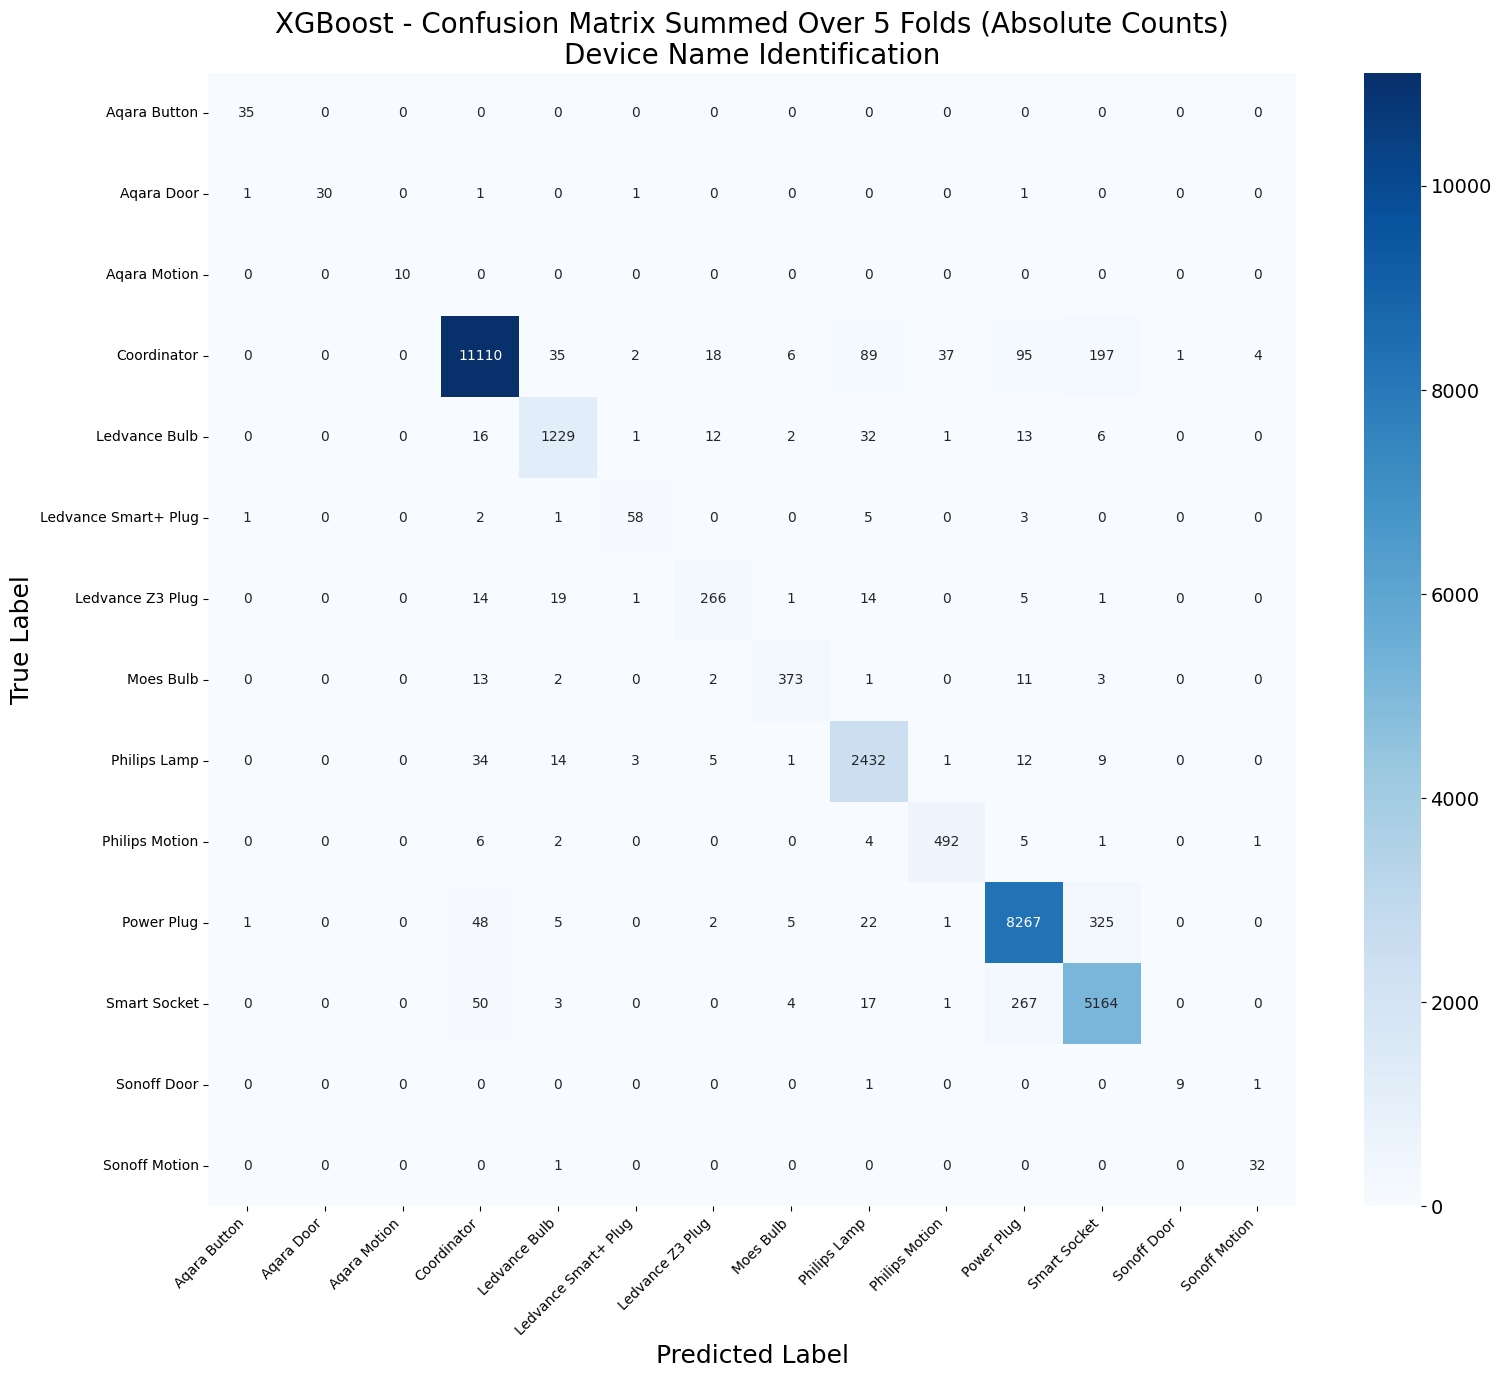

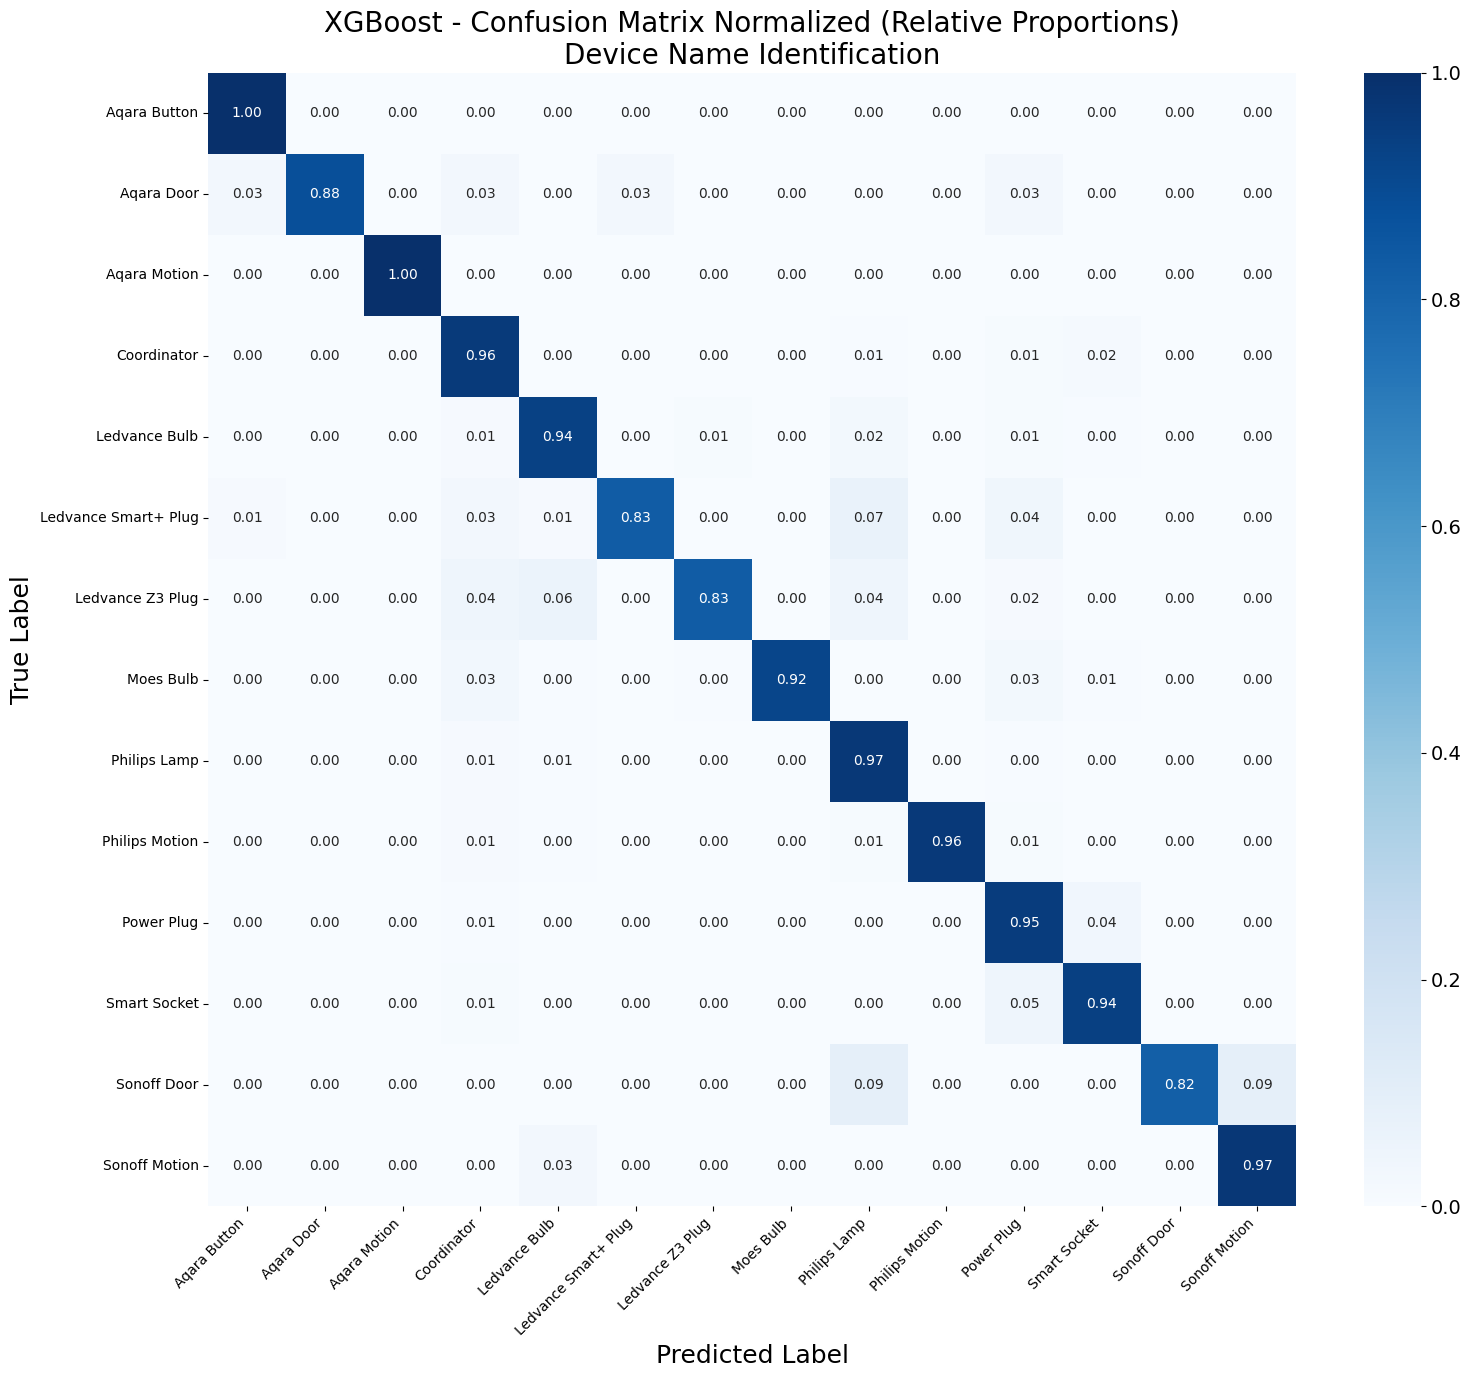


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_xgboost_confusion_matrix_absolute.png
  - identification_xgboost_confusion_matrix_relative.png


In [62]:
# Identification with 5-Fold Cross-Validation using XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, col_name = "Device Name",  min_samples=2):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data[col_name].isin(classes_to_keep)].copy()
    return filtered_data

def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized

data["Device Name General"] = data["Device Name"].apply(generalize_device_name)

data = filter_small_classes(data, col_name="Device Name General", min_samples=2)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"])



y = data["Device Name General"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Convert class weights to sample weights for XGBoost
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        colsample_bytree=0.4,
        gamma=0,
        learning_rate=0.2,
        max_depth=10,
        min_child_weight=0.2,
        n_estimators=300,
        subsample=0.8
    )
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict
    y_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_xgboost_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_xgboost_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_xgboost_confusion_matrix_absolute.png")
print("  - identification_xgboost_confusion_matrix_relative.png")


DEVICE TAXONOMY REFERENCE (Ordered B-O, PANC)
B            : Sonoff Motion (SNZB-03)
C            : Sonoff Door (SNZB-04)
D            : Aqara Motion P1 (MS-S02)
E            : Aqara Door (DW-S02D)
G            : Aqara Button (WB-R02D)
H            : Tuya Socket (EU-16A)
I            : Senckit Plug
J            : Ledvance Z3 Plug
K            : Ledvance Smart+ Plug
L            : Ledvance Bulb
M            : Moes Bulb (GU10)
N            : Philips Lamp (LWA019)
O            : Philips Motion (SML001)
PANC         : Personal Area Network Coordinator (Zigbee Hub)



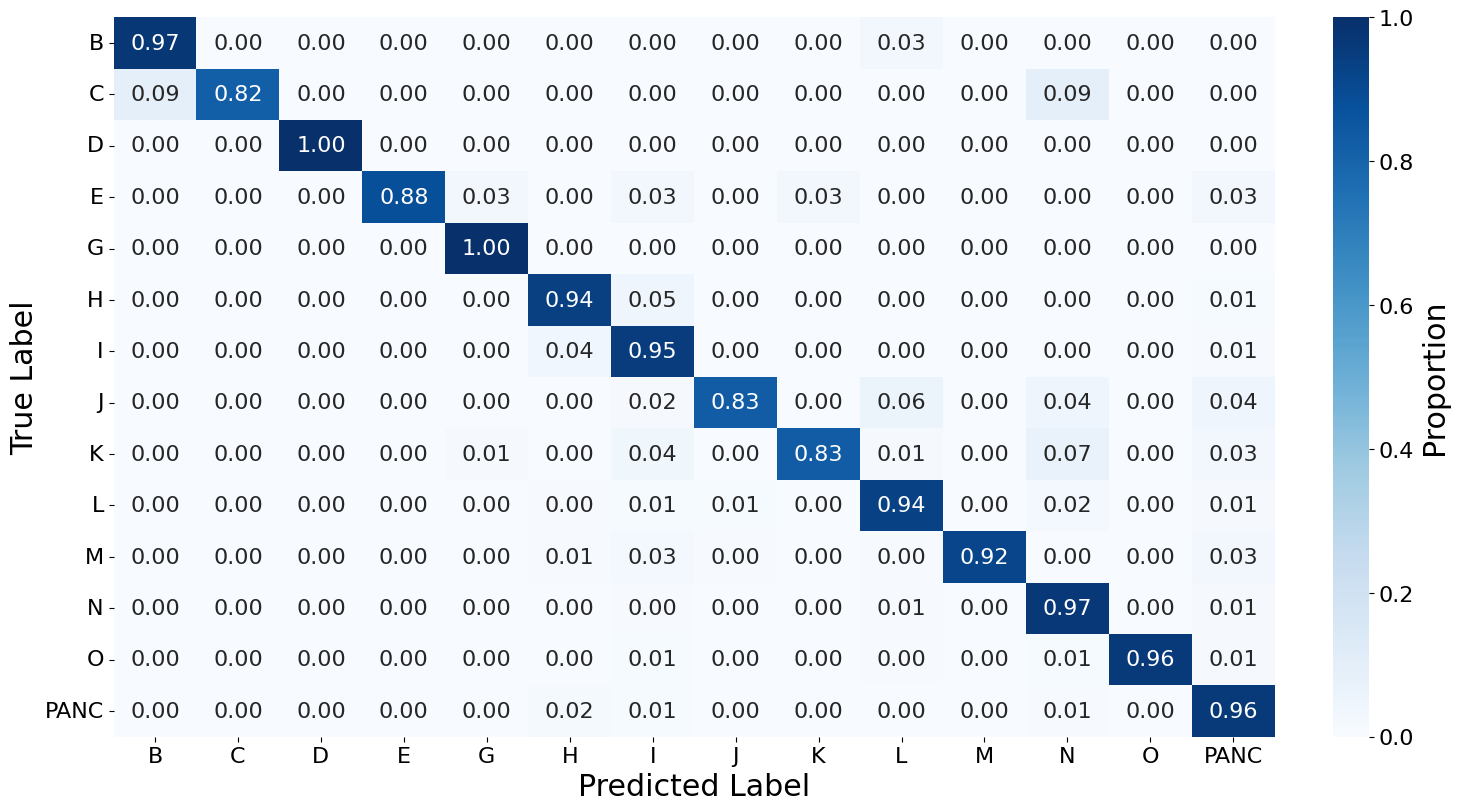


Confusion matrices saved to ./figures/
  - confusion_matrix_absolute_device_type_topoB.pdf
  - confusion_matrix_relative_device_type_topoB.pdf

CLASSIFICATION REPORT (with standardized labels, ordered A-O)
Label           Precision    Recall       F1-Score     Support     
-----------------------------------------------------------------
B               0.00         0.00         0.00         0           
C               0.00         0.00         0.00         0           
D               0.98         0.96         0.97         11594       
E               0.92         0.97         0.94         35          
G               0.94         0.98         0.96         4228        
H               0.00         0.00         0.00         0           
I               0.00         0.00         0.00         0           
J               0.00         0.00         0.00         0           
K               0.98         0.98         0.98         14573       
L               0.92         0.97         0.94 

In [78]:
#save categories relative_cm and summed_cm for later use if not already saved
import numpy as np
import os
import pandas as pd
if not os.path.exists('categories_device_name_topoB.npy'):
    np.save('categories_device_name_topoB.npy', categories)
else:
    #load and compare
    categories = np.load('categories_device_name_topoB.npy', allow_pickle=True)

if not os.path.exists('summed_cm_device_name_topoB.npy'):
    np.save('summed_cm_device_name_topoB.npy', summed_cm)
else:
    #load and compare
    summed_cm = np.load('summed_cm_device_name_topoB.npy', allow_pickle=True)

if not os.path.exists('relative_cm_device_name_topoB.npy'):
    np.save('relative_cm_device_name_topoB.npy', relative_cm)
else:
    #load and compare
    relative_cm = np.load('relative_cm_device_name_topoB.npy', allow_pickle=True)




# ========== DEVICE LABEL MAPPING AND REORDERING ==========
# Taxonomic mapping: Original device designations to standardized nomenclature
device_label_mapping = {
    'Coordinator': 'PANC',          # Personal Area Network Coordinator (Zigbee Hub)
    'Sonoff Motion': 'B',           # SNZB-03, Motion Sensor
    'Sonoff Door': 'C',             # SNZB-04, Door Sensor
    'Aqara Motion': 'D',            # MS-S02, Motion Sensor P1
    'Aqara Door': 'E',              # DW-S02D, Door and Window Sensor
    'Aqara Button': 'G',            # WB-R02D, Mini Switch
    'Smart Socket': 'H',            # Tuya Smart Socket EU-16A
    'Power Plug': 'I',              # Senckit Smart Power Plug
    'Ledvance Z3 Plug': 'J',        # 4058075208513, Z3 Plug
    'Ledvance Smart+ Plug': 'K',    # 4058075729261, Smart+ Plug
    'Ledvance Bulb': 'L',           # 4058075208391, Smart+ Bulb
    'Moes Bulb': 'M',               # GU10, Bulb
    'Philips Lamp': 'N',            # LWA019, HueLamp
    'Philips Motion': 'O'           # SML001, HueMotion
}

# Comprehensive device descriptions for methodological documentation
device_descriptions = {
    'B': 'Sonoff Motion (SNZB-03)',
    'C': 'Sonoff Door (SNZB-04)',
    'D': 'Aqara Motion P1 (MS-S02)',
    'E': 'Aqara Door (DW-S02D)',
    'G': 'Aqara Button (WB-R02D)',
    'H': 'Tuya Socket (EU-16A)',
    'I': 'Senckit Plug',
    'J': 'Ledvance Z3 Plug',
    'K': 'Ledvance Smart+ Plug',
    'L': 'Ledvance Bulb',
    'M': 'Moes Bulb (GU10)',
    'N': 'Philips Lamp (LWA019)',
    'O': 'Philips Motion (SML001)',
    'PANC': 'Personal Area Network Coordinator (Zigbee Hub)'
}

# Create label list for categories that exist in data
category_labels = []
for cat in categories:
    if cat in device_label_mapping:
        category_labels.append(device_label_mapping[cat])
    else:
        category_labels.append(cat)  # Preserve original nomenclature if unmapped

# Define canonical ordering: Alphabetical sequence (B-O) followed by PANC
# This positions the network coordinator at the terminal position
existing_labels_set = set(category_labels)
desired_order = ['B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'PANC']
ordered_labels = [label for label in desired_order if label in existing_labels_set]

# Create reordering indices for confusion matrix reorganization
label_to_idx = {label: idx for idx, label in enumerate(category_labels)}
reorder_indices = [label_to_idx[label] for label in ordered_labels]

# Apply reordering transformation to confusion matrix
summed_cm_reordered = summed_cm[np.ix_(reorder_indices, reorder_indices)]

# Compute row-normalized relative confusion matrix
relative_cm_reordered = summed_cm_reordered.astype('float')
row_sums = relative_cm_reordered.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # Prevent division by zero
relative_cm_reordered = relative_cm_reordered / row_sums

# Methodological documentation: Device taxonomy reference
print("\n" + "=" * 80)
print("DEVICE TAXONOMY REFERENCE (Ordered B-O, PANC)")
print("=" * 80)
for label in ordered_labels:
    print(f"{label:12s} : {device_descriptions[label]}")
print("=" * 80 + "\n")


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl

# Reset to defaults and apply consistent styling parameters
mpl.rcdefaults()
mpl.rcdefaults()
plt.rcParams.update({'font.size': 18})

# ========== PLOT 2: Relative Confusion Matrix ==========
fig2, ax2 = plt.subplots(figsize=(14.5, 8), layout="constrained")

sns.heatmap(
    relative_cm_reordered, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=ordered_labels, 
    yticklabels=ordered_labels, 
    annot_kws={"size": 16, "weight": "normal"},
    vmin=0,
    vmax=1,
    linewidths=0,
    linecolor='lightgray',
    ax=ax2
)

ax2.set_xlabel("Predicted Label", fontsize='large')
ax2.set_ylabel("True Label", fontsize='large')
# ax2.set_title("Confusion Matrix - Normalized Proportions (Row-wise)", 
            #   fontsize=15, fontweight='bold', pad=15)
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=16, rotation=0)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=16, rotation=0)

# Adjust colorbar font size
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=16)
cbar2.set_label('Proportion', fontsize='large')


plt.savefig('./figures/confusion_matrix_relative_device_name_topoB.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


print("\nConfusion matrices saved to ./figures/")
print("  - confusion_matrix_absolute_device_type_topoB.pdf")
print("  - confusion_matrix_relative_device_type_topoB.pdf")

# ========== CLASSIFICATION REPORT WITH NEW LABELS ==========
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT (with standardized labels, ordered A-O)")
print("=" * 80)

# Get report as dictionary for easier manipulation
report_dict = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0,
    output_dict=True
)

print(f"{'Label':<15s} {'Precision':<12s} {'Recall':<12s} {'F1-Score':<12s} {'Support':<12s}")
print("-" * 65)

# Print metrics in new label order
for label in ordered_labels:
    # Find original category name
    original_cat = categories[category_labels.index(label)]
    metrics = report_dict[original_cat]
    
    print(f"{label:<15s} {metrics['precision']:<12.2f} {metrics['recall']:<12.2f} "
          f"{metrics['f1-score']:<12.2f} {int(metrics['support']):<12d}")

# Print overall metrics
print("-" * 65)
print(f"{'Accuracy':<15s} {'':<12s} {'':<12s} {report_dict['accuracy']:<12.2f} "
      f"{int(report_dict['macro avg']['support']):<12d}")
print(f"{'Macro Avg':<15s} {report_dict['macro avg']['precision']:<12.2f} "
      f"{report_dict['macro avg']['recall']:<12.2f} "
      f"{report_dict['macro avg']['f1-score']:<12.2f} "
      f"{int(report_dict['macro avg']['support']):<12d}")
print(f"{'Weighted Avg':<15s} {report_dict['weighted avg']['precision']:<12.2f} "
      f"{report_dict['weighted avg']['recall']:<12.2f} "
      f"{report_dict['weighted avg']['f1-score']:<12.2f} "
      f"{int(report_dict['weighted avg']['support']):<12d}")
print("=" * 80 + "\n")

## Train A Test B

Category distribution:
2    8650
5    8300
0    3839
4     206
3      69
1      17
Name: count, dtype: int64


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:01:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        Bulb   0.673087  0.876064  0.761278      4228
      Button   0.536585  0.628571  0.578947        35
 Coordinator   0.902073  0.938330  0.919844     11594
        Door   0.553571  0.688889  0.613861        45
      Motion   0.814727  0.619134  0.703590       554
      Socket   0.946710  0.841145  0.890811     14573

    accuracy                       0.877792     31029
   macro avg   0.737792  0.765355  0.744722     31029
weighted avg   0.889358  0.877792  0.879913     31029

Weighed F1-Score: 0.8799


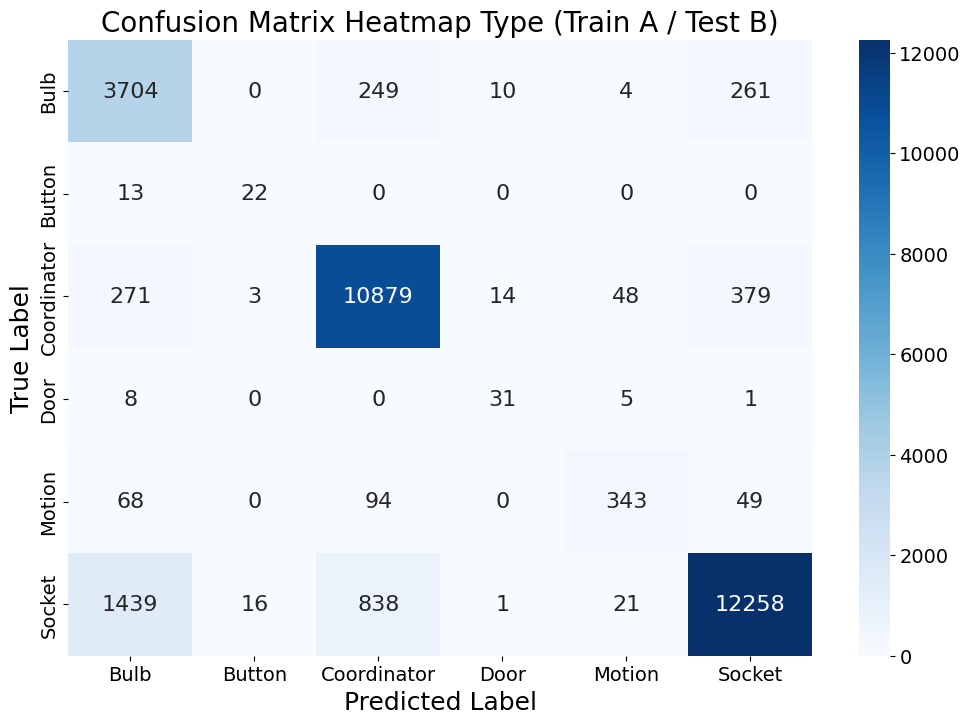

In [92]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data[feature_columns]
y_test = test_data["Device Type"]

y_test = test_data["Device Type"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

# unique_classes = pd.Series(y_train).unique()
# class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
# class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}



# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced", 
    classes=np.unique(y_train), 
    y=y_train
)
    
# Convert class weights to sample weights for XGBoost
sample_weights = np.array([class_weights[i] for i in y_train])
    
# Train XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',  # For multi-class classification
    use_label_encoder=False,
    colsample_bytree=0.4,
    gamma=0,
    learning_rate=0.2,
    max_depth=8,
    min_child_weight=0.5,
    n_estimators=300,
    subsample=1
)


xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = xgb_model.predict(X_test_filtered)


actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0,digits=6)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighed F1-Score: {f1_macro:.4f}")





plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
5    14573
2    11594
0     4228
4      554
3       45
1       35
Name: count, dtype: int64


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:03:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        Bulb   0.800378  0.772858  0.786377      3839
      Button   0.333333  0.705882  0.452830        17
 Coordinator   0.908874  0.834798  0.870262      8650
        Door   0.695652  0.231884  0.347826        69
      Motion   0.574257  0.563107  0.568627       206
      Socket   0.828425  0.915060  0.869590      8300

    accuracy                       0.850387     21081
   macro avg   0.690153  0.670598  0.649252     21081
weighted avg   0.853010  0.850387  0.849727     21081

Weighed F1-Score: 0.8497


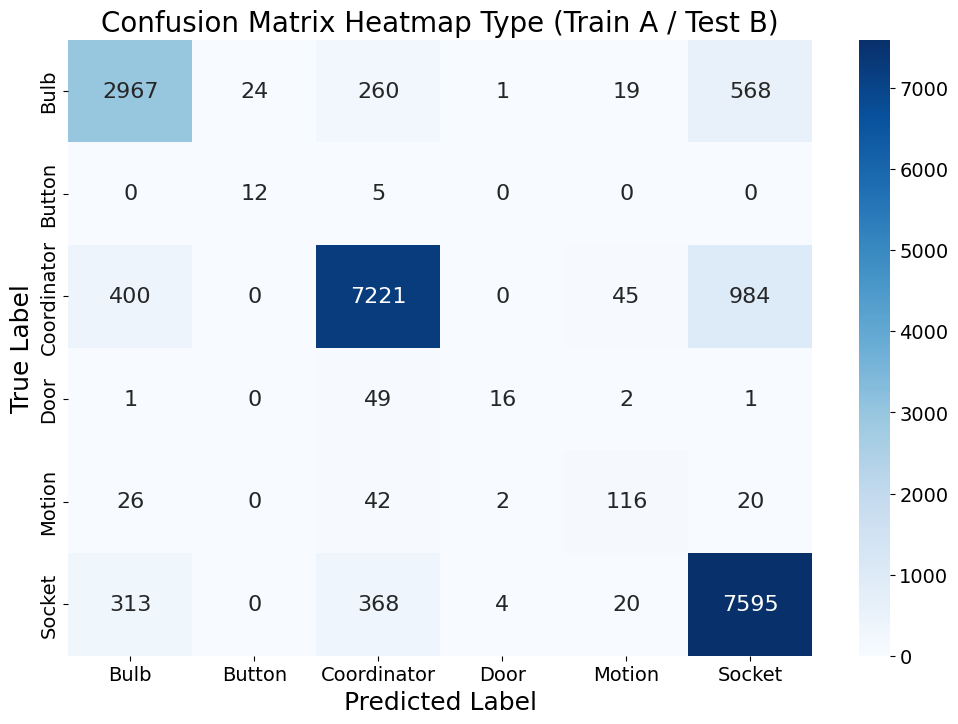

In [93]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data[feature_columns]
y_test = test_data["Device Type"]

y_test = test_data["Device Type"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

# unique_classes = pd.Series(y_train).unique()
# class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
# class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}



# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced", 
    classes=np.unique(y_train), 
    y=y_train
)
    
# Convert class weights to sample weights for XGBoost
sample_weights = np.array([class_weights[i] for i in y_train])
    
# Train XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',  # For multi-class classification
    use_label_encoder=False,
    colsample_bytree=0.4,
    gamma=0,
    learning_rate=0.2,
    max_depth=8,
    min_child_weight=0.5,
    n_estimators=300,
    subsample=1
)


xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = xgb_model.predict(X_test_filtered)


actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0,digits=6)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighed F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

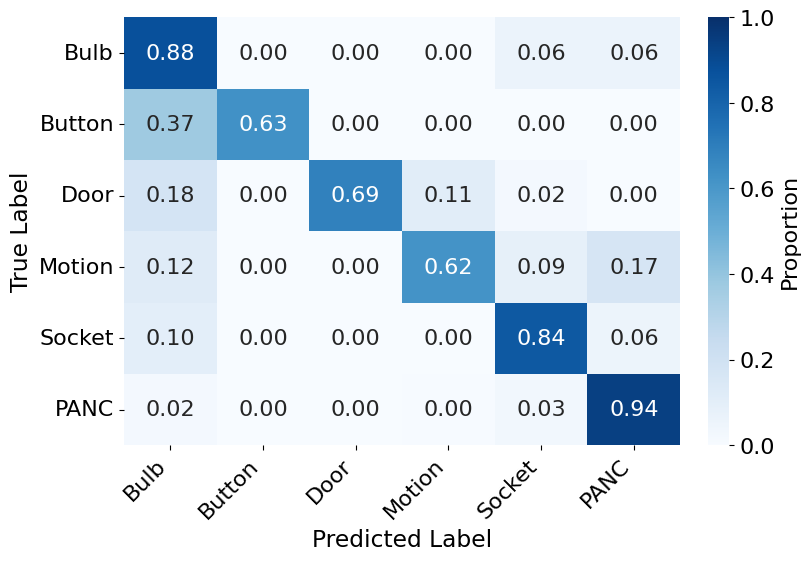

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl

relative_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Reset to defaults and apply consistent styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# Define the new category order with Coordinator → PANC moved to the end
new_order = ['Bulb', 'Button', 'Door', 'Motion', 'Socket', 'PANC']

# Get indices for reordering based on original categories
# Original: ['Bulb', 'Button', 'Coordinator', 'Door', 'Motion', 'Socket']
original_categories = categories.tolist()
reorder_indices = []
for cat in new_order:
    if cat == 'PANC':
        reorder_indices.append(original_categories.index('Coordinator'))
    else:
        reorder_indices.append(original_categories.index(cat))

# Reorder confusion matrix (both rows and columns)
relative_cm_reordered = relative_cm[np.ix_(reorder_indices, reorder_indices)]

# ========== PLOT: Relative Confusion Matrix with PANC at end ==========
fig2, ax2 = plt.subplots(figsize=(8, 5.5), layout="constrained")

sns.heatmap(
    relative_cm_reordered, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=new_order, 
    yticklabels=new_order, 
    
    annot_kws={"size": 16, "weight": "normal"},
    vmin=0,
    vmax=1,
    linewidths=0,
    linecolor='lightgray',
    ax=ax2
)

ax2.set_xlabel("Predicted Label", fontsize='large')
ax2.set_ylabel("True Label", fontsize='large')
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=16, rotation=45, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=16, rotation=0)

# Adjust colorbar font size
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=16)
cbar2.set_label('Proportion', fontsize=16)

plt.savefig('./figures/confusion_matrix_relative_device_type_topo(trainAoverB).pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

Category distribution:
3     8650
10    4991
11    2949
8     1400
4     1165
9      742
7      726
6      221
5      139
1       62
0       17
13      10
12       7
2        2
Name: count, dtype: int64


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:25:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                      precision    recall  f1-score   support

        Aqara Button   0.742857  0.742857  0.742857        35
          Aqara Door   0.694444  0.735294  0.714286        34
        Aqara Motion   0.000000  0.000000  0.000000        10
         Coordinator   0.882949  0.931689  0.906664     11594
       Ledvance Bulb   0.636045  0.691311  0.662527      1312
Ledvance Smart+ Plug   0.250000  0.142857  0.181818        70
    Ledvance Z3 Plug   0.161111  0.090343  0.115768       321
           Moes Bulb   0.290068  0.634568  0.398141       405
        Philips Lamp   0.537439  0.483074  0.508809      2511
      Philips Motion   0.002814  0.005871  0.003805       511
          Power Plug   0.683197  0.633587  0.657457      8676
        Smart Socket   0.540716  0.469125  0.502383      5506
         Sonoff Door   0.160000  0.363636  0.222222        11
       Sonoff Motion   0.588235  0.303030  0.400000        33

            accuracy                       0.688582     31029
      

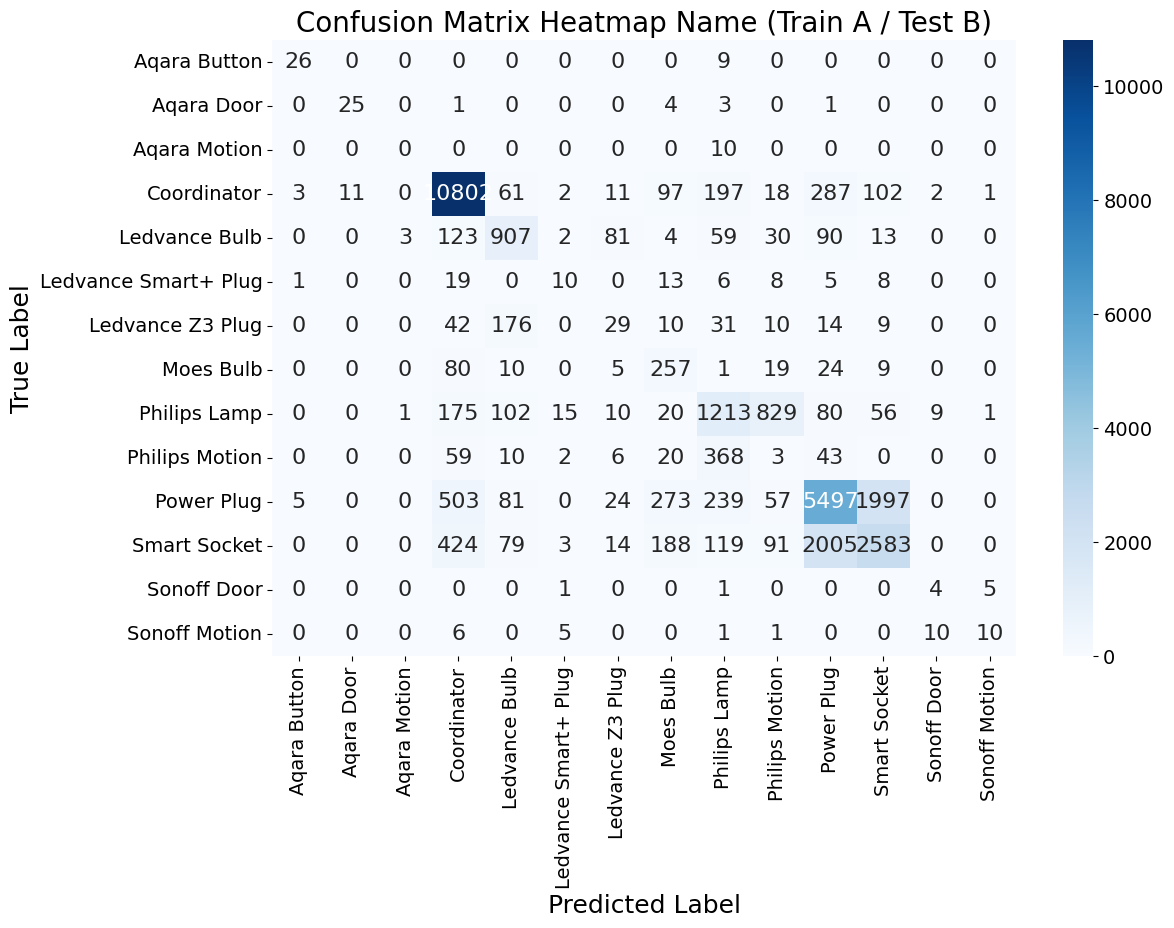

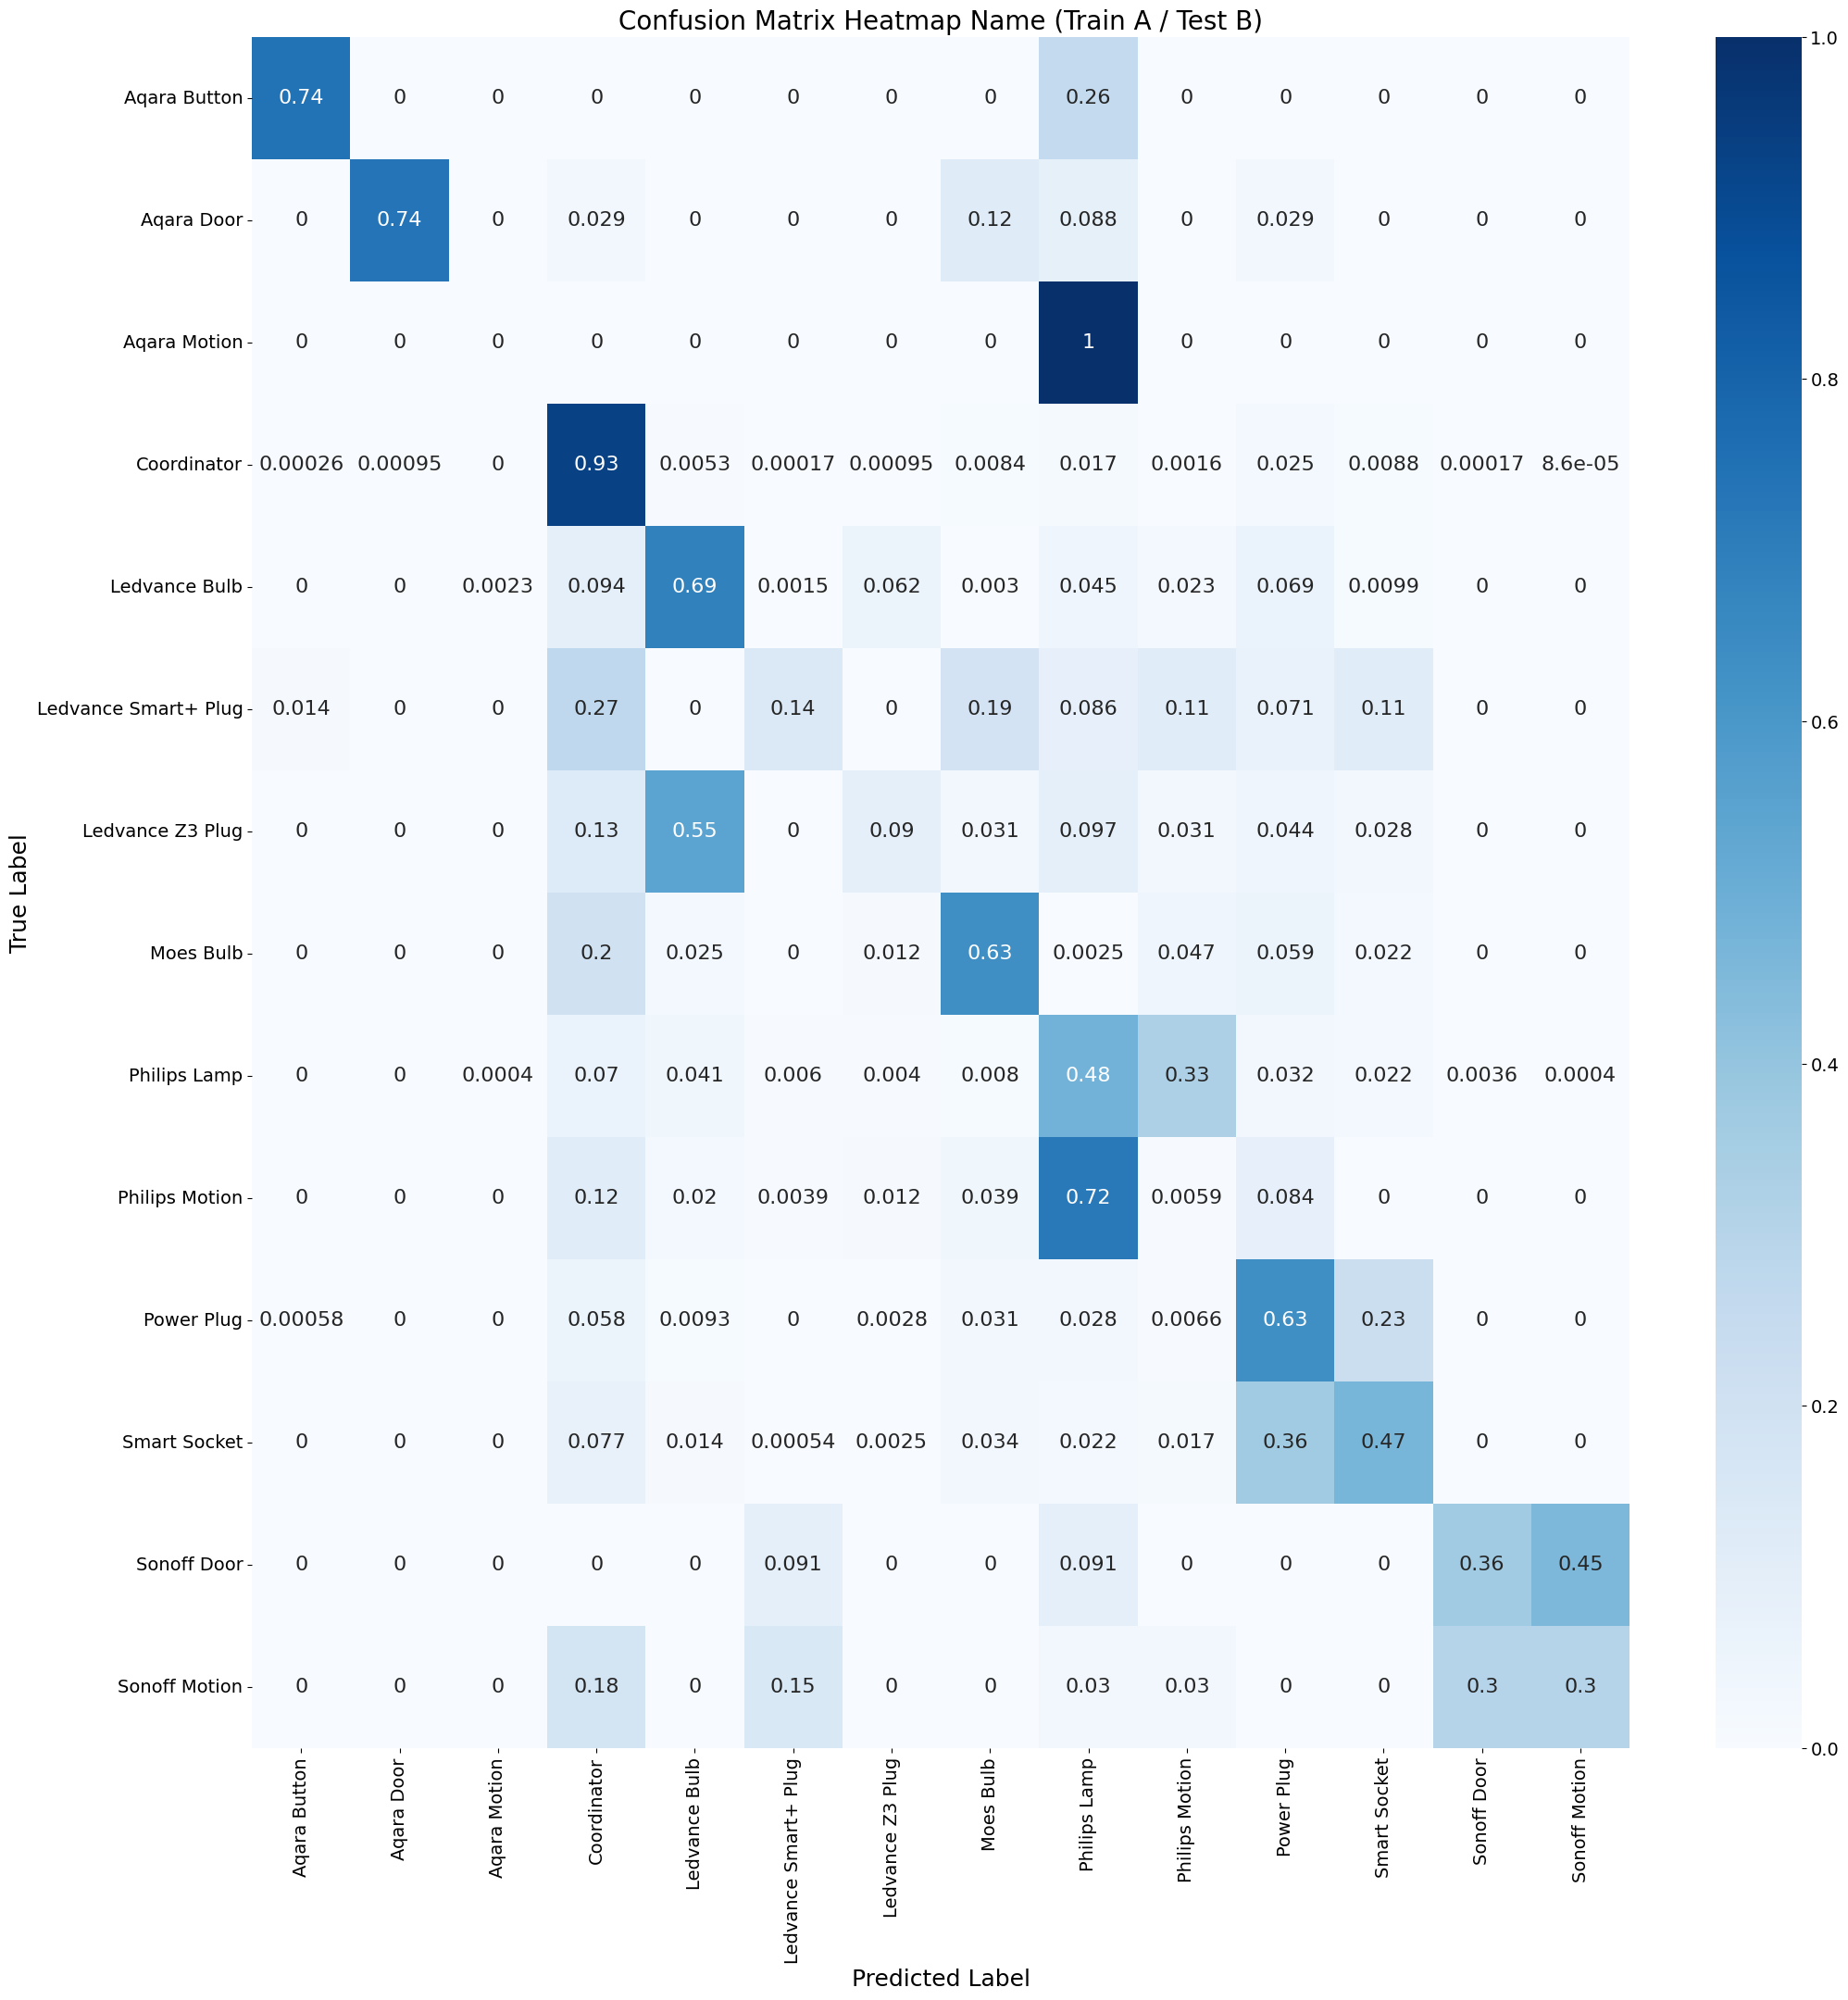

In [94]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

def filter_small_classes(data, col_name = "Device Name",  min_samples=2):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data[col_name].isin(classes_to_keep)].copy()
    return filtered_data


def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized
train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)



train_data["Device Name General"] = train_data["Device Name"].apply(generalize_device_name)

train_data = filter_small_classes(train_data, col_name="Device Name General", min_samples=2)


X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Name General"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

test_data["Device Name General"] = test_data["Device Name"].apply(generalize_device_name)

test_data = filter_small_classes(test_data, col_name="Device Name General", min_samples=10)


X_test = test_data[feature_columns]
y_test = test_data["Device Name General"]

y_test = test_data["Device Name General"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}


# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced", 
    classes=np.unique(y_train), 
    y=y_train
)

# Convert class weights to sample weights for XGBoost
sample_weights = np.array([class_weights[i] for i in y_train])

# Train XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',  # For multi-class classification
    use_label_encoder=False,
    colsample_bytree=0.4,
    gamma=0,
    learning_rate=0.2,
    max_depth=10,
    min_child_weight=0.2,
    n_estimators=300,
    subsample=0.8
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = xgb_model.predict(X_test_filtered)
    


# rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
# rf_model.fit(X_train, y_train)

# y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0,digits=6)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


relative_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(24, 24))
sns.heatmap(relative_cm, annot=True, cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
3     11594
10     8676
11     5506
8      2511
4      1312
9       511
7       405
6       321
5        70
0        35
1        34
13       33
12       11
2        10
Name: count, dtype: int64


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:04:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                      precision    recall  f1-score   support

        Aqara Button       0.30      0.47      0.36        17
          Aqara Door       0.87      0.53      0.66        62
        Aqara Motion       0.12      0.50      0.20         2
         Coordinator       0.90      0.82      0.86      8650
       Ledvance Bulb       0.74      0.67      0.71      1165
Ledvance Smart+ Plug       0.28      0.06      0.11       139
    Ledvance Z3 Plug       0.13      0.05      0.08       221
           Moes Bulb       0.72      0.31      0.43       726
        Philips Lamp       0.46      0.70      0.55      1400
      Philips Motion       0.03      0.01      0.01       742
          Power Plug       0.58      0.68      0.63      4991
        Smart Socket       0.51      0.58      0.54      2949
         Sonoff Door       0.57      0.57      0.57         7
       Sonoff Motion       0.05      0.10      0.07        10

            accuracy                           0.68     21081
      

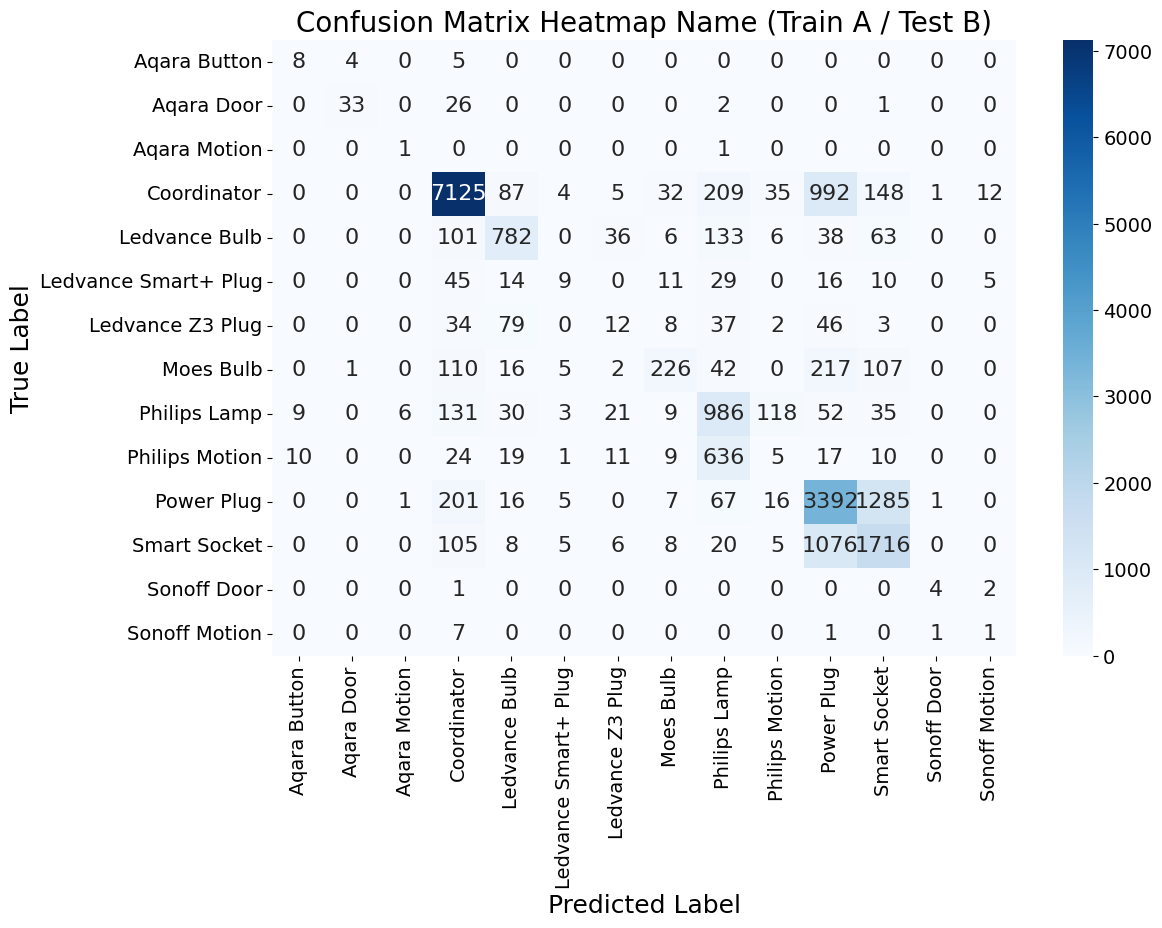

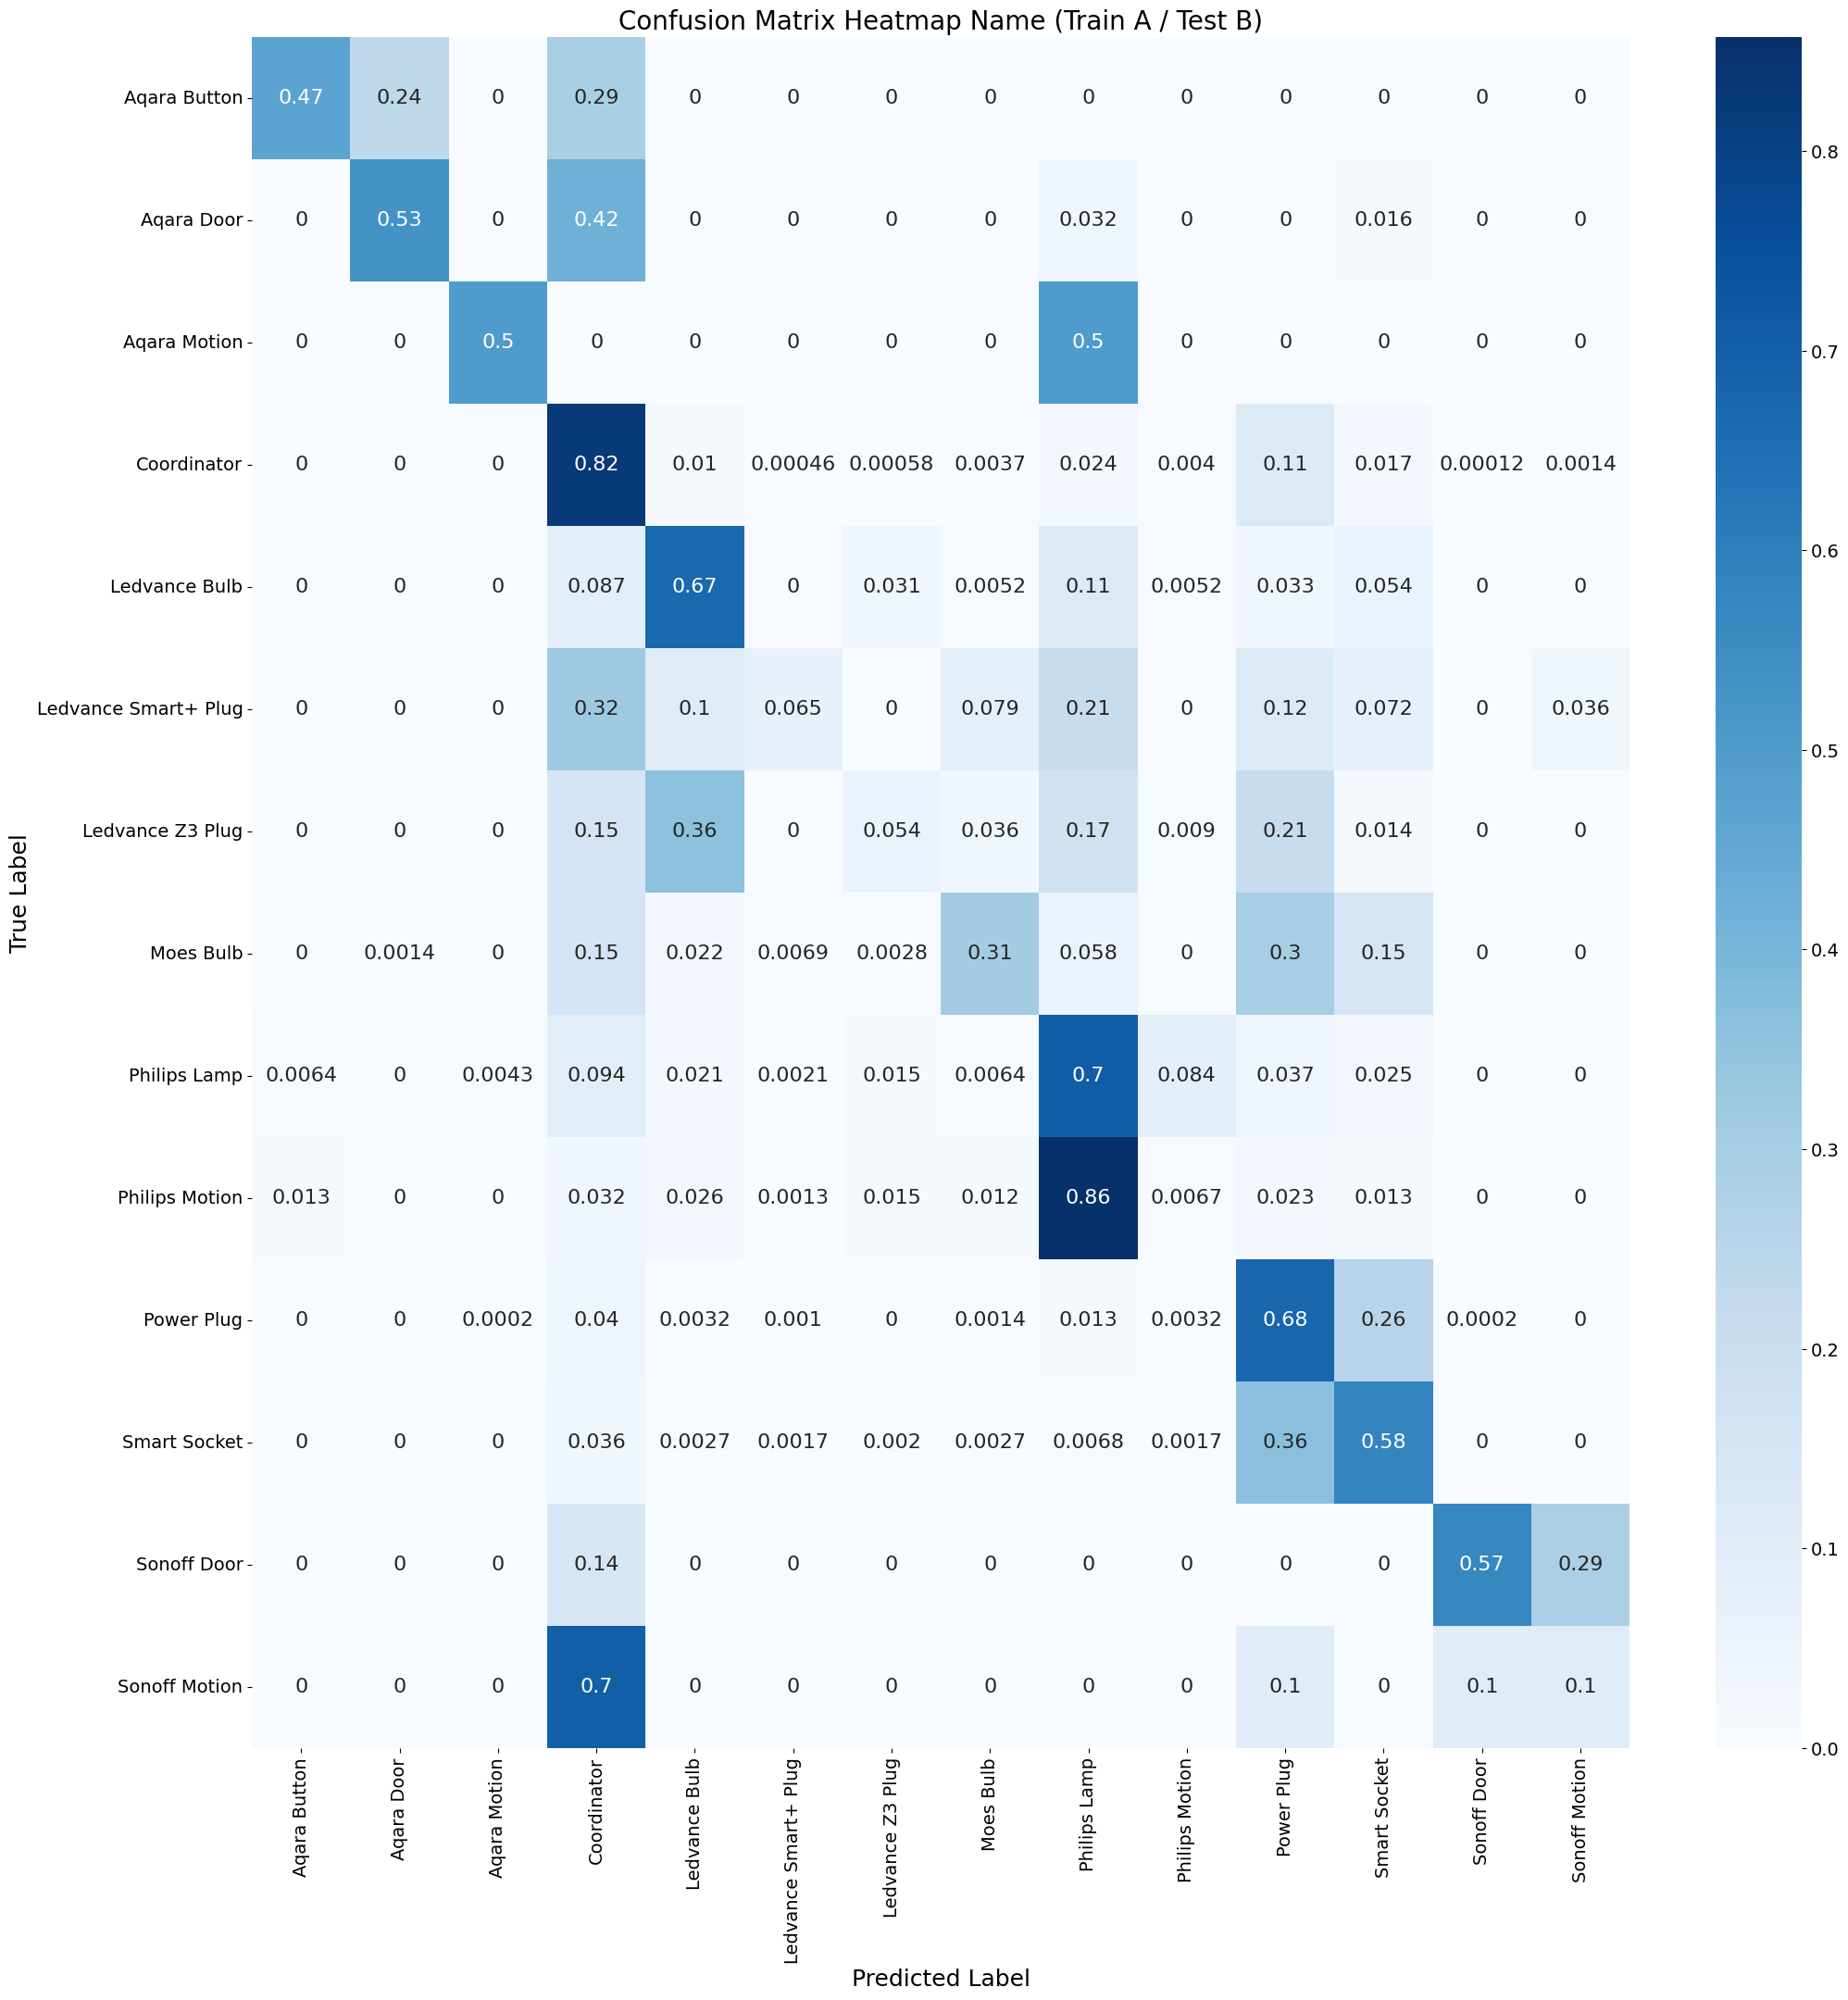

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

def filter_small_classes(data, col_name = "Device Name",  min_samples=2):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data[col_name].isin(classes_to_keep)].copy()
    return filtered_data


def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized
train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)



train_data["Device Name General"] = train_data["Device Name"].apply(generalize_device_name)

train_data = filter_small_classes(train_data, col_name="Device Name General", min_samples=2)


X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Name General"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

test_data["Device Name General"] = test_data["Device Name"].apply(generalize_device_name)

test_data = filter_small_classes(test_data, col_name="Device Name General", min_samples=10)


X_test = test_data[feature_columns]
y_test = test_data["Device Name General"]

y_test = test_data["Device Name General"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}


# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced", 
    classes=np.unique(y_train), 
    y=y_train
)

# Convert class weights to sample weights for XGBoost
sample_weights = np.array([class_weights[i] for i in y_train])

# Train XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',  # For multi-class classification
    use_label_encoder=False,
    colsample_bytree=0.4,
    gamma=0,
    learning_rate=0.2,
    max_depth=10,
    min_child_weight=0.2,
    n_estimators=300,
    subsample=0.8
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = xgb_model.predict(X_test_filtered)
    


# rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
# rf_model.fit(X_train, y_train)

# y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


relative_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(24, 24))
sns.heatmap(relative_cm, annot=True, cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Train B Test A

Category distribution:
5    14573
2    11594
0     4228
4      554
3       45
1       35
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.83      0.72      0.77      3839
      Button       0.55      0.35      0.43        17
 Coordinator       0.88      0.82      0.85      8650
        Door       0.89      0.46      0.61        69
      Motion       0.63      0.50      0.56       206
      Socket       0.80      0.91      0.85      8300

    accuracy                           0.83     21081
   macro avg       0.76      0.63      0.68     21081
weighted avg       0.84      0.83      0.83     21081

Weighed F1-Score: 0.8317


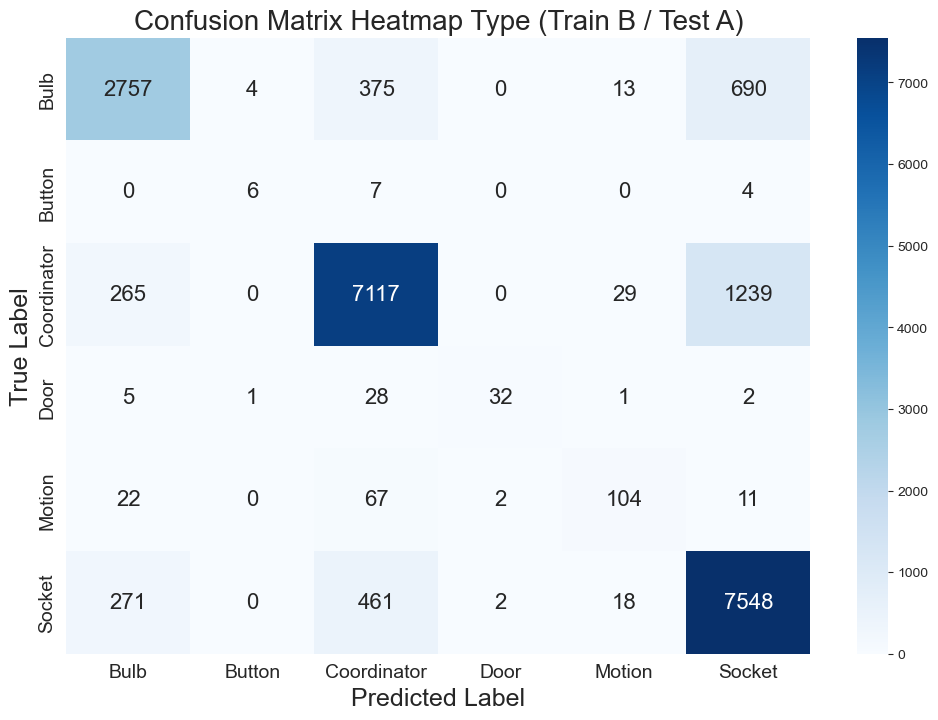

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

# 加载测试数据
test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data[feature_columns]
y_test = test_data["Device Type"]

y_test = test_data["Device Type"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighed F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train B / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
2     11594
13     5506
11     4682
12     3994
3      1312
7      1184
9       942
10      511
6       405
8       385
5       321
4        70
0        35
14       33
1        29
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.60      0.35      0.44        17
         Coordinator       0.87      0.84      0.85      8650
       Ledvance Bulb       0.69      0.67      0.68      1165
Ledvance Smart+ Plug       0.24      0.06      0.10       139
    Ledvance Z3 Plug       0.15      0.07      0.09       221
           Moes Bulb       0.69      0.19      0.29       726
      Philips Lamp 1       0.30      0.47      0.36       669
      Philips Lamp 2       0.19      0.09      0.12       537
      Philips Lamp 3       0.00      0.01      0.00       194
      Philips Motion       0.01      0.00      0.00       742
        Power Plug 1       0.35      0.37      0.36      2385
        Power Plug 2      

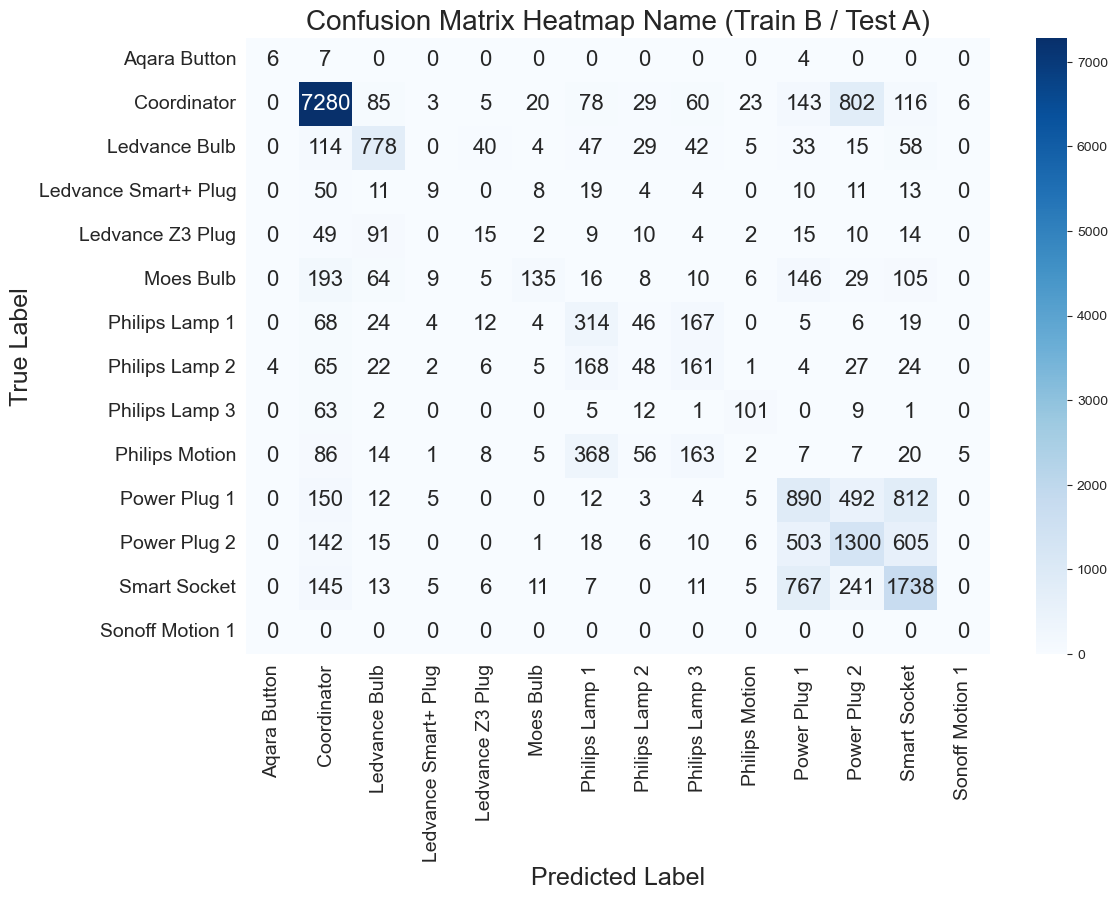

In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)
train_data = filter_small_classes(train_data)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)
test_data = filter_small_classes(test_data)

X_test = test_data[feature_columns]
y_test = test_data["Device Name"]

y_test = test_data["Device Name"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train B / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()